
# Transformer Regression Sanity Check

This notebook benchmarks a **plain supervised regressor** built on the repo's
`ObservationEncoder` against tabular baselines for predicting a **single stellar parameter**
from the observed inputs.

The goal is not to beat the SBI models. It is to answer a narrower question:

- does the transformer encoder learn a useful representation from the missingness-aware photometry/astrometry?
- does that representation outperform strong non-neural tabular baselines on the same task?
- does the answer change when we train on a **naturally imbalanced** subset vs a **uniform age-mass-bin** subset?

The notebook supports:

- multiple targets, e.g. `logAge`, `m_init`, `feh`
- multiple training subsets
- evaluation on both natural-distribution and balanced age-mass-bin test subsets
- optional reuse of an existing `test_indices.npy`

The transformer regressor here reuses the same `ObservationEncoder` class that the SBI models use,
so this is a fairly direct architecture sanity check.


In [19]:
from __future__ import annotations

import copy
import json
import math
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data.py').exists() and (candidate / 'encoder.py').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from the current working directory.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from columns import OBS_COLS
from data import DEFAULT_INPUT_COLS, build_sbi_arrays, load_cache_arrays
from encoder import ObservationEncoder
from value_transforms import apply_inverse_value_transforms_numpy

print(f'Repo root: {REPO_ROOT}')
print(f'Torch device available: cuda={torch.cuda.is_available()}')


Repo root: /n/home12/sratzenboeck/code/sbi_variants
Torch device available: cuda=True


In [20]:
# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

from project_paths import (
    NOTEBOOK_BENCHMARK_OUTPUT_DIR,
    REAL_CACHE_PATH,
    REAL_MODEL_DIR,
    REAL_TEST_INDEX_PATH,
)

CACHE_ENV = os.environ.get('SBI_CACHE_PATH')
TEST_INDEX_ENV = os.environ.get('SBI_TEST_INDEX_PATH')
SPLIT_DIR_ENV = os.environ.get('SBI_SPLIT_DIR')

CACHE_PATH = Path(CACHE_ENV).expanduser() if CACHE_ENV else REAL_CACHE_PATH
TEST_INDEX_PATH = Path(TEST_INDEX_ENV).expanduser() if TEST_INDEX_ENV else REAL_TEST_INDEX_PATH
SPLIT_DIR = Path(SPLIT_DIR_ENV).expanduser() if SPLIT_DIR_ENV else (REAL_MODEL_DIR / 'age_regime_splits')

TRAIN_ALL_INDEX_PATH = SPLIT_DIR / 'train_indices_all.npy'
VAL_ALL_INDEX_PATH = SPLIT_DIR / 'val_indices_all.npy'
TRAIN_BALANCED_INDEX_PATH = SPLIT_DIR / 'train_indices_age_balanced.npy'
VAL_BALANCED_INDEX_PATH = SPLIT_DIR / 'val_indices_age_balanced.npy'
BALANCED_EVAL_INDEX_PATH = SPLIT_DIR / 'eval_indices_balanced_age_300k.npy'
YOUNG_TEST_INDEX_PATH = REAL_MODEL_DIR / 'young_test_indices_logAge_lt_7p8.npy'

assert CACHE_PATH is not None and CACHE_PATH.exists(), (
    'Set SBI_CACHE_PATH in the environment or edit this cell to point to build_arrays_cache.npz.'
)
for required_path in [
    TEST_INDEX_PATH,
    TRAIN_ALL_INDEX_PATH,
    VAL_ALL_INDEX_PATH,
    TRAIN_BALANCED_INDEX_PATH,
    VAL_BALANCED_INDEX_PATH,
    BALANCED_EVAL_INDEX_PATH,
    YOUNG_TEST_INDEX_PATH,
]:
    assert required_path.exists(), f'Required split file not found: {required_path}'

TARGET_COLUMNS = ['logAge', 'm_init']
INPUT_COLUMNS = list(DEFAULT_INPUT_COLS)
USE_COLORS = True

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
VAL_SUBSET_SIZE = 25_000
YOUNG_LOGAGE_THRESHOLD = 7.8

TRAIN_SUBSET_SPECS = [
    {
        'name': 'natural_fixed_100k',
        'pool': 'natural',
        'kind': 'random',
        'n_rows': 100_000,
    },
    {
        'name': 'age_balanced_fixed_100k',
        'pool': 'balanced',
        'kind': 'random',
        'n_rows': 100_000,
    },
]

EVAL_SUBSET_SPECS = [
    {
        'name': 'natural_test_50k',
        'pool': 'natural_test',
        'kind': 'random',
        'n_rows': 50_000,
    },
    {
        'name': 'balanced_age_50k',
        'pool': 'balanced_eval',
        'kind': 'random',
        'n_rows': 50_000,
    },
    {
        'name': 'young_test_all',
        'pool': 'young_test',
        'kind': 'random',
        'n_rows': None,
    },
]

TRANSFORMER_CONFIG = {
    'dim_value': 24,
    'dim_id': 24,
    'dim_error': 16,
    'dim_observed': 8,
    'attn_embed_dim': 128,
    'num_heads': 8,
    'num_layers': 4,
    'widening_factor': 4,
    'dropout': 0.05,
    'use_missingness_context': True,
    'missingness_context_hidden_dim': 64,
    'head_hidden_dim': 256,
    'batch_size': 2048,
    'epochs': 80,
    'lr': 3e-4,
    'lr_min': 1e-5,
    'weight_decay': 1e-4,
    'patience': 12,
    'huber_delta': 1.0,
}

TRANSFORMER_VARIANTS = [
    {
        'name': 'transformer_encoder_regressor',
        'sampler': 'shuffle',
        'use_importance_weights': False,
    },
    {
        'name': 'transformer_joint_curriculum_iw_regressor',
        'sampler': 'uniform_age_mass',
        'use_importance_weights': True,
        'n_age_bins': 25,
        'n_mass_bins': 12,
        'bin_strategy': 'equal_width',
    },
]

RANDOM_FOREST_CONFIG = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'n_jobs': -1,
    'random_state': SEED,
}

HGB_CONFIG = {
    'loss': 'squared_error',
    'learning_rate': 0.05,
    'max_depth': 8,
    'max_iter': 300,
    'min_samples_leaf': 50,
    'random_state': SEED,
    'early_stopping': False,
}

OUTPUT_DIR = NOTEBOOK_BENCHMARK_OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

print('CACHE_PATH                =', CACHE_PATH)
print('TEST_INDEX_PATH           =', TEST_INDEX_PATH)
print('SPLIT_DIR                 =', SPLIT_DIR)
print('TRAIN_ALL_INDEX_PATH      =', TRAIN_ALL_INDEX_PATH)
print('TRAIN_BALANCED_INDEX_PATH =', TRAIN_BALANCED_INDEX_PATH)
print('BALANCED_EVAL_INDEX_PATH  =', BALANCED_EVAL_INDEX_PATH)
print('YOUNG_TEST_INDEX_PATH     =', YOUNG_TEST_INDEX_PATH)
print('DEVICE                    =', DEVICE)
print('OUTPUT_DIR                =', OUTPUT_DIR)


CACHE_PATH                = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/build_arrays_cache.npz
TEST_INDEX_PATH           = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/test_indices.npy
SPLIT_DIR                 = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/age_regime_splits
TRAIN_ALL_INDEX_PATH      = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/age_regime_splits/train_indices_all.npy
TRAIN_BALANCED_INDEX_PATH = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/age_regime_splits/train_indices_age_balanced.npy
BALANCED_EVAL_INDEX_PATH  = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/age_regime_splits/eval_indices_balanced_age_300k.npy
YOUNG_TEST_INDEX_PATH     = /n/holystore01/LABS/itc_lab/Lab/to-Sebastian/nf_sbi_colors/young_test_indices_logAge_lt_7p8.npy
DEVICE                    = cuda
OUTPUT_DIR                = /n/home12/sratzenboeck/code/sbi_variants/notebooks/outputs/transformer_regression_benchmark


In [21]:
# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def column_index(columns: list[str], name: str) -> int:
    return {str(c): i for i, c in enumerate(columns)}[str(name)]


def denormalize_columns(cache, values_norm: np.ndarray, columns: list[str]) -> np.ndarray:
    idx = np.asarray([column_index(cache.columns, c) for c in columns], dtype=np.int64)
    arr = np.asarray(values_norm, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    raw = arr * cache.stds[idx] + cache.means[idx]
    raw = apply_inverse_value_transforms_numpy(
        raw,
        transform_names=np.asarray(cache.value_transform_names[idx], dtype=object),
        transform_params=np.asarray(cache.value_transform_params[idx], dtype=np.float32),
    )
    return raw


def denormalize_target(cache, values_norm_1d: np.ndarray, target_col: str) -> np.ndarray:
    return denormalize_columns(cache, np.asarray(values_norm_1d, dtype=np.float32), [target_col]).reshape(-1)


def _build_edges(values: np.ndarray, n_bins: int, strategy: str) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    if strategy == 'quantile':
        edges = np.quantile(values, np.linspace(0.0, 1.0, n_bins + 1))
    elif strategy == 'equal_width':
        vmin = float(values.min())
        vmax = float(values.max())
        if vmax <= vmin:
            vmax = vmin + 1e-6
        edges = np.linspace(vmin, vmax, n_bins + 1)
    else:
        raise ValueError(f'Unknown bin strategy: {strategy}')

    eps = max(np.finfo(np.float64).eps * max(float(np.max(np.abs(values))), 1.0), 1e-12)
    edges = np.asarray(edges, dtype=np.float64)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + eps
    if edges[-1] <= edges[-2]:
        edges[-1] = edges[-2] + eps
    return edges


def prepare_age_mass_bin_state(
    cache,
    row_indices: np.ndarray,
    *,
    n_age_bins: int,
    n_mass_bins: int,
    bin_strategy: str = 'equal_width',
) -> dict:
    rows = np.asarray(row_indices, dtype=np.int64)
    age_mass = denormalize_columns(
        cache,
        cache.values_norm[rows][:, [column_index(cache.columns, 'logAge'), column_index(cache.columns, 'm_init')]],
        ['logAge', 'm_init'],
    )
    age = age_mass[:, 0]
    mass = age_mass[:, 1]

    age_edges = _build_edges(age, n_age_bins, bin_strategy)
    mass_edges = _build_edges(mass, n_mass_bins, bin_strategy)

    age_bin = np.searchsorted(age_edges, age, side='right') - 1
    mass_bin = np.searchsorted(mass_edges, mass, side='right') - 1
    age_bin = np.clip(age_bin, 0, n_age_bins - 1)
    mass_bin = np.clip(mass_bin, 0, n_mass_bins - 1)
    joint = age_bin * n_mass_bins + mass_bin

    bins: dict[int, np.ndarray] = {}
    for b in np.unique(joint):
        bins[int(b)] = rows[joint == b]

    return {
        'rows': rows,
        'joint': joint.astype(np.int64),
        'bins': bins,
        'active_bins': np.asarray(sorted(bins.keys()), dtype=np.int64),
        'age_edges': age_edges,
        'mass_edges': mass_edges,
        'n_age_bins': int(n_age_bins),
        'n_mass_bins': int(n_mass_bins),
    }


def sample_uniform_over_age_mass_bins(
    cache,
    row_indices: np.ndarray,
    *,
    total_size: int,
    n_age_bins: int,
    n_mass_bins: int,
    bin_strategy: str = 'equal_width',
    replace: bool = True,
    seed: int = 0,
) -> np.ndarray:
    if total_size <= 0:
        raise ValueError('total_size must be > 0')

    state = prepare_age_mass_bin_state(
        cache,
        row_indices,
        n_age_bins=n_age_bins,
        n_mass_bins=n_mass_bins,
        bin_strategy=bin_strategy,
    )
    bins = state['bins']
    active_bins = state['active_bins']
    rng = np.random.default_rng(seed)

    if replace:
        chosen_bins = rng.choice(active_bins, size=total_size, replace=True)
        sampled = np.empty(total_size, dtype=np.int64)
        for b in active_bins:
            mask = chosen_bins == b
            n = int(mask.sum())
            if n == 0:
                continue
            sampled[mask] = rng.choice(bins[int(b)], size=n, replace=True)
        return sampled.astype(np.int64)

    per_bin = int(math.ceil(total_size / max(len(active_bins), 1)))
    selected_chunks = []
    leftovers = []
    for b in active_bins:
        rows_b = np.asarray(bins[int(b)], dtype=np.int64)
        take = min(per_bin, len(rows_b))
        if take > 0:
            chosen = rng.choice(rows_b, size=take, replace=False)
            selected_chunks.append(chosen)
            if take < len(rows_b):
                remaining = np.setdiff1d(rows_b, chosen, assume_unique=False)
                if len(remaining) > 0:
                    leftovers.append(remaining)

    if not selected_chunks:
        raise RuntimeError('No active age-mass bins available for sampling.')

    selected = np.concatenate(selected_chunks).astype(np.int64)
    if len(selected) > total_size:
        selected = rng.choice(selected, size=total_size, replace=False).astype(np.int64)
    elif len(selected) < total_size and leftovers:
        remaining_pool = np.concatenate(leftovers).astype(np.int64)
        n_extra = min(total_size - len(selected), len(remaining_pool))
        extra = rng.choice(remaining_pool, size=n_extra, replace=False).astype(np.int64)
        selected = np.concatenate([selected, extra]).astype(np.int64)

    return selected


def select_subset_rows(cache, pool_rows: np.ndarray, spec: dict, *, seed: int) -> np.ndarray:
    kind = spec['kind']
    n_rows = spec.get('n_rows')
    rng = np.random.default_rng(seed)
    pool_rows = np.asarray(pool_rows, dtype=np.int64)

    if kind == 'random':
        if n_rows is None or n_rows >= len(pool_rows):
            return np.sort(pool_rows.copy())
        return np.sort(rng.choice(pool_rows, size=n_rows, replace=False).astype(np.int64))

    if kind == 'uniform_age_mass':
        assert n_rows is not None, 'uniform_age_mass subsets require n_rows'
        return np.sort(sample_uniform_over_age_mass_bins(
            cache,
            pool_rows,
            total_size=n_rows,
            n_age_bins=int(spec.get('n_age_bins', 25)),
            n_mass_bins=int(spec.get('n_mass_bins', 12)),
            bin_strategy=str(spec.get('bin_strategy', 'equal_width')),
            replace=bool(spec.get('replace', True)),
            seed=seed,
        ))

    raise ValueError(f'Unknown subset kind: {kind}')


def make_matching_val_spec(spec: dict, val_subset_size: int) -> dict:
    val_spec = dict(spec)
    val_spec['name'] = f"{spec['name']}_val"
    val_spec['n_rows'] = val_subset_size
    if val_spec['kind'] == 'uniform_age_mass':
        val_spec['replace'] = False
    return val_spec


def build_subset_map(cache, train_pools: dict, val_pools: dict, eval_pools: dict):
    train_subset_rows = {}
    val_subset_rows = {}
    eval_subset_rows = {}

    for i, spec in enumerate(TRAIN_SUBSET_SPECS):
        pool_name = spec['pool']
        pool_rows = np.asarray(train_pools[pool_name], dtype=np.int64)
        train_subset_rows[spec['name']] = select_subset_rows(cache, pool_rows, spec, seed=SEED + 10 * (i + 1))

        val_pool_rows = np.asarray(val_pools[pool_name], dtype=np.int64)
        val_spec = make_matching_val_spec(spec, val_subset_size=min(VAL_SUBSET_SIZE, len(val_pool_rows)))
        val_subset_rows[spec['name']] = select_subset_rows(cache, val_pool_rows, val_spec, seed=SEED + 100 + 10 * (i + 1))

    for i, spec in enumerate(EVAL_SUBSET_SPECS):
        pool_name = spec['pool']
        pool_rows = np.asarray(eval_pools[pool_name], dtype=np.int64)
        eval_subset_rows[spec['name']] = select_subset_rows(cache, pool_rows, spec, seed=SEED + 200 + 10 * (i + 1))

    return train_subset_rows, val_subset_rows, eval_subset_rows


def plot_age_mass_distributions(cache, subset_rows: dict[str, np.ndarray], *, title_prefix: str = '') -> None:
    names = list(subset_rows.keys())
    ncols = min(3, max(1, len(names)))
    nrows = int(math.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)

    for ax, name in zip(axes.ravel(), names):
        rows = np.asarray(subset_rows[name], dtype=np.int64)
        age_mass = denormalize_columns(
            cache,
            cache.values_norm[rows][:, [column_index(cache.columns, 'logAge'), column_index(cache.columns, 'm_init')]],
            ['logAge', 'm_init'],
        )
        hb = ax.hexbin(age_mass[:, 0], age_mass[:, 1], gridsize=45, mincnt=1, cmap='viridis')
        ax.set_title(f"{title_prefix}{name}\nN={len(rows):,}")
        ax.set_xlabel('logAge')
        ax.set_ylabel('m_init')
        fig.colorbar(hb, ax=ax, label='count')

    for ax in axes.ravel()[len(names):]:
        ax.axis('off')

    fig.tight_layout()
    plt.show()


In [22]:
# ------------------------------------------------------------------
# Load cache and construct fixed train/val/test pools + subset views
# ------------------------------------------------------------------

set_seed(SEED)
cache = load_cache_arrays(str(CACHE_PATH))

train_pools = {
    'natural': np.unique(np.load(TRAIN_ALL_INDEX_PATH).astype(np.int64)),
    'balanced': np.unique(np.load(TRAIN_BALANCED_INDEX_PATH).astype(np.int64)),
}
val_pools = {
    'natural': np.unique(np.load(VAL_ALL_INDEX_PATH).astype(np.int64)),
    'balanced': np.unique(np.load(VAL_BALANCED_INDEX_PATH).astype(np.int64)),
}
eval_pools = {
    'natural_test': np.unique(np.load(TEST_INDEX_PATH).astype(np.int64)),
    'balanced_eval': np.unique(np.load(BALANCED_EVAL_INDEX_PATH).astype(np.int64)),
    'young_test': np.unique(np.load(YOUNG_TEST_INDEX_PATH).astype(np.int64)),
}

test_pool_rows = eval_pools['natural_test']

train_subset_rows, val_subset_rows, eval_subset_rows = build_subset_map(
    cache,
    train_pools,
    val_pools,
    eval_pools,
)

summary_rows = []
for pool_name, rows in train_pools.items():
    summary_rows.append({'split_group': 'train_pool', 'subset': pool_name, 'n_rows': len(rows)})
for pool_name, rows in val_pools.items():
    summary_rows.append({'split_group': 'val_pool', 'subset': pool_name, 'n_rows': len(rows)})
for pool_name, rows in eval_pools.items():
    summary_rows.append({'split_group': 'eval_pool', 'subset': pool_name, 'n_rows': len(rows)})
for name, rows in train_subset_rows.items():
    summary_rows.append({'split_group': 'train_subset', 'subset': name, 'n_rows': len(rows)})
for name, rows in val_subset_rows.items():
    summary_rows.append({'split_group': 'val_subset', 'subset': name, 'n_rows': len(rows)})
for name, rows in eval_subset_rows.items():
    summary_rows.append({'split_group': 'eval_subset', 'subset': name, 'n_rows': len(rows)})

display(pd.DataFrame(summary_rows))


,split_group,subset,n_rows
0,train_pool,natural,58338455
1,train_pool,balanced,703296
2,val_pool,natural,6482052
3,val_pool,balanced,78147
4,eval_pool,natural_test,3411606
5,eval_pool,balanced_eval,218055
6,eval_pool,young_test,18055
7,train_subset,natural_fixed_100k,100000
8,train_subset,age_balanced_fixed_100k,100000
9,val_subset,natural_fixed_100k,25000


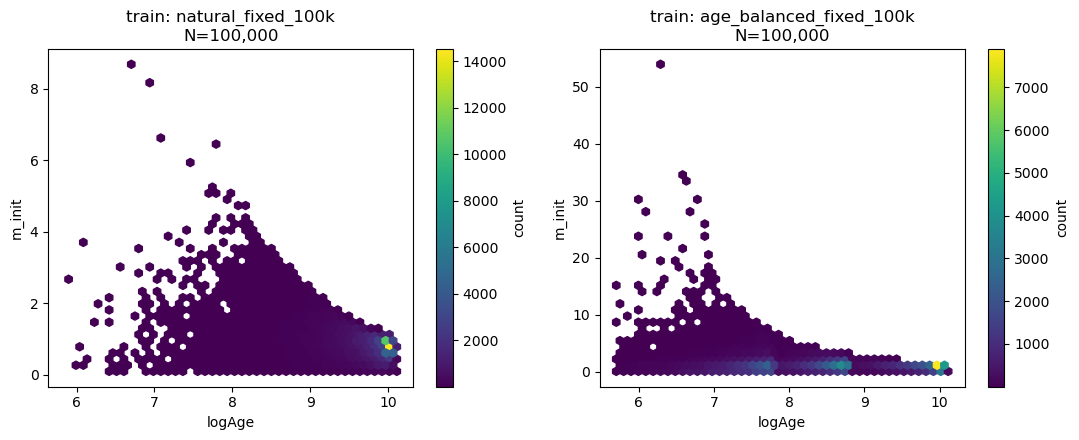

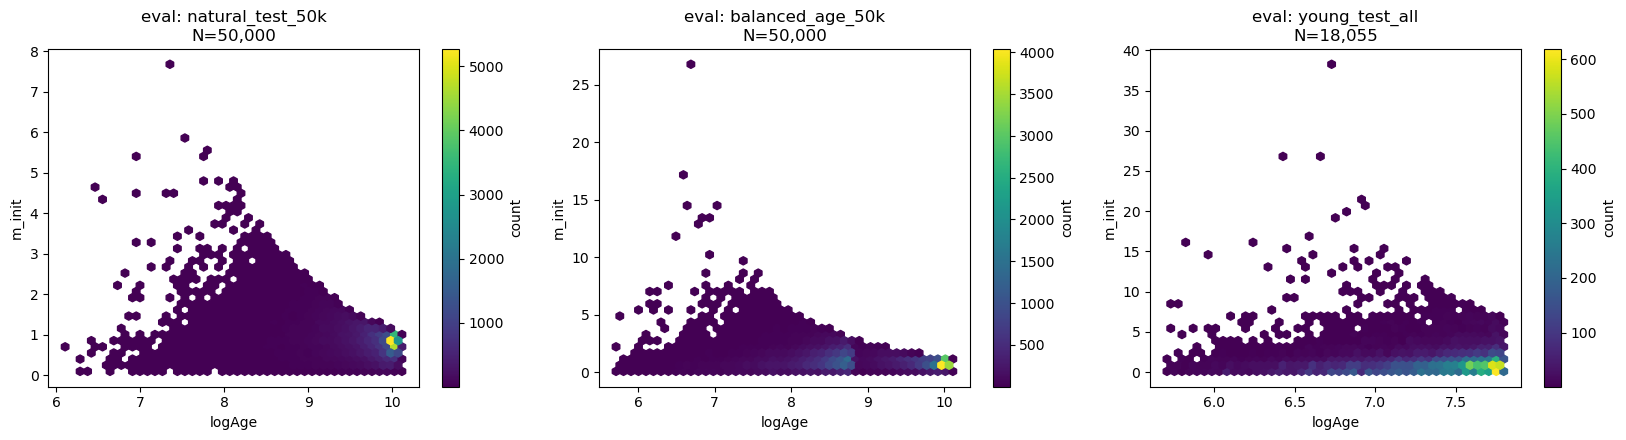

In [23]:
plot_age_mass_distributions(cache, train_subset_rows, title_prefix='train: ')
plot_age_mass_distributions(cache, eval_subset_rows, title_prefix='eval: ')

In [24]:
from matplotlib.colors import LogNorm


def compute_age_mass_hist(cache, rows, *, n_age_bins=25, n_mass_bins=12, bin_strategy="equal_width", ref_rows=None):
    rows = np.asarray(rows, dtype=np.int64)
    if ref_rows is None:
        ref_rows = rows
    ref_rows = np.asarray(ref_rows, dtype=np.int64)

    ref_age_mass = denormalize_columns(
        cache,
        cache.values_norm[ref_rows][:, [
            column_index(cache.columns, "logAge"),
            column_index(cache.columns, "m_init"),
        ]],
        ["logAge", "m_init"],
    )
    age_edges = _build_edges(ref_age_mass[:, 0], n_age_bins, bin_strategy)
    mass_edges = _build_edges(ref_age_mass[:, 1], n_mass_bins, bin_strategy)

    age_mass = denormalize_columns(
        cache,
        cache.values_norm[rows][:, [
            column_index(cache.columns, "logAge"),
            column_index(cache.columns, "m_init"),
        ]],
        ["logAge", "m_init"],
    )

    hist, _, _ = np.histogram2d(
        age_mass[:, 0],
        age_mass[:, 1],
        bins=[age_edges, mass_edges],
    )
    return hist, age_edges, mass_edges


def plot_sampler_bin_comparison(
    cache,
    rows_a,
    rows_b,
    *,
    label_a="A",
    label_b="B",
    n_age_bins=25,
    n_mass_bins=12,
    bin_strategy="equal_width",
    ref_rows=None,
):
    hist_a, age_edges, mass_edges = compute_age_mass_hist(
        cache, rows_a,
        n_age_bins=n_age_bins,
        n_mass_bins=n_mass_bins,
        bin_strategy=bin_strategy,
        ref_rows=ref_rows,
    )
    hist_b, _, _ = compute_age_mass_hist(
        cache, rows_b,
        n_age_bins=n_age_bins,
        n_mass_bins=n_mass_bins,
        bin_strategy=bin_strategy,
        ref_rows=ref_rows if ref_rows is not None else rows_a,
    )

    p_a = hist_a / max(hist_a.sum(), 1.0)
    p_b = hist_b / max(hist_b.sum(), 1.0)
    ratio = (p_b + 1e-12) / (p_a + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    im0 = axes[0].imshow(
        p_a.T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        norm=LogNorm()
    )
    axes[0].set_title(f"{label_a} bin probability")
    axes[0].set_xlabel("logAge bin")
    axes[0].set_ylabel("m_init bin")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(
        p_b.T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        norm=LogNorm()
    )
    axes[1].set_title(f"{label_b} bin probability")
    axes[1].set_xlabel("logAge bin")
    axes[1].set_ylabel("m_init bin")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(
        np.log10(ratio).T,
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
        vmin=-2,
        vmax=2,
    )
    axes[2].set_title(f"log10({label_b} / {label_a})")
    axes[2].set_xlabel("logAge bin")
    axes[2].set_ylabel("m_init bin")
    plt.colorbar(im2, ax=axes[2])
    plt.show()

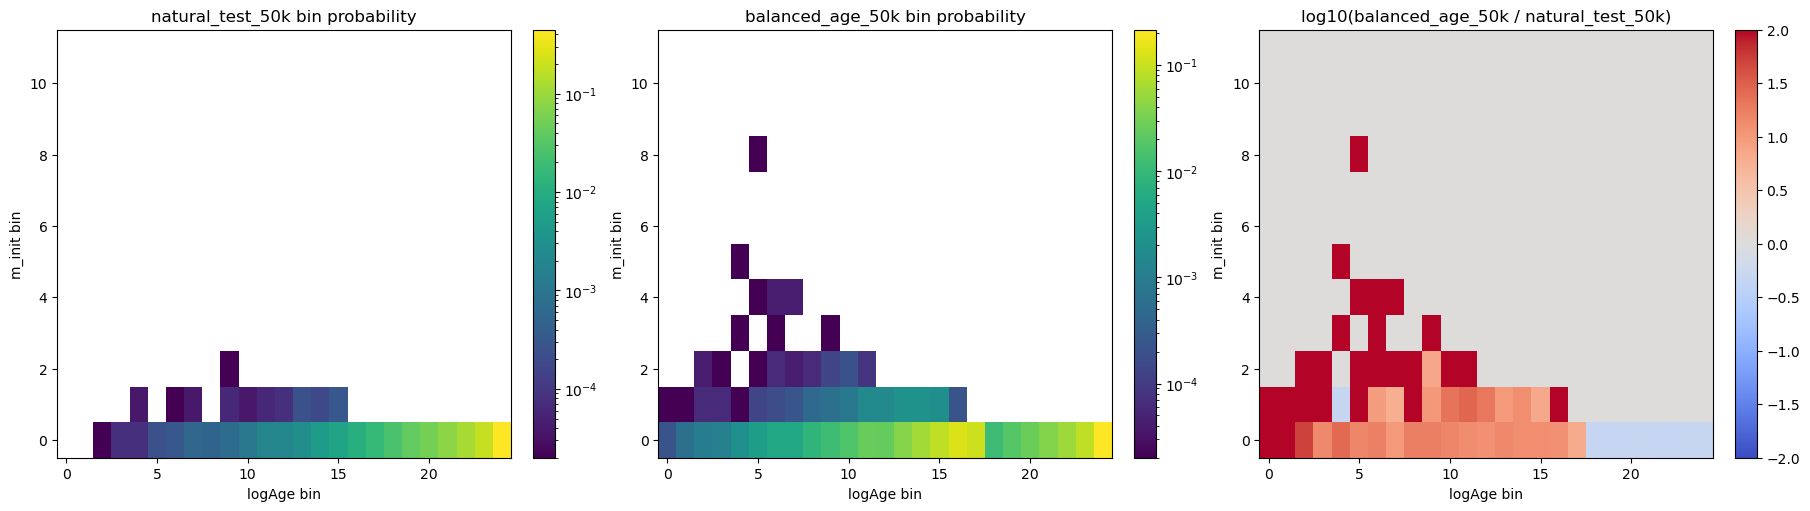

In [25]:
plot_sampler_bin_comparison(
    cache,
    eval_subset_rows["natural_test_50k"],
    eval_subset_rows["balanced_age_50k"],
    label_a="natural_test_50k",
    label_b="balanced_age_50k",
    n_age_bins=25,
    n_mass_bins=12,
    bin_strategy="equal_width",
    ref_rows=test_pool_rows,
)


In [26]:
def summarize_bin_distribution(p, label):
    flat = p.ravel()
    active = flat[flat > 0]
    return pd.Series(
        {
            "label": label,
            "n_active_bins": len(active),
            "min_p": active.min(),
            "median_p": np.median(active),
            "max_p": active.max(),
            "cv": active.std() / active.mean(),
            "entropy_frac": -(active * np.log(active)).sum() / np.log(len(active)),
        }
    )

hist_nat, _, _ = compute_age_mass_hist(
    cache,
    eval_subset_rows["natural_test_50k"],
    n_age_bins=25,
    n_mass_bins=12,
    bin_strategy="equal_width",
    ref_rows=test_pool_rows,
)
hist_bal, _, _ = compute_age_mass_hist(
    cache,
    eval_subset_rows["balanced_age_50k"],
    n_age_bins=25,
    n_mass_bins=12,
    bin_strategy="equal_width",
    ref_rows=test_pool_rows,
)

p_nat = hist_nat / hist_nat.sum()
p_bal = hist_bal / hist_bal.sum()

display(pd.DataFrame([
    summarize_bin_distribution(p_nat, "natural_test_50k"),
    summarize_bin_distribution(p_bal, "balanced_age_50k"),
]))

tv = 0.5 * np.abs(p_nat - p_bal).sum()
print("total variation distance:", tv)
print("max log10 ratio:", np.max(np.abs(np.log10((p_bal + 1e-12) / (p_nat + 1e-12)))))


,label,n_active_bins,min_p,median_p,max_p,cv,entropy_frac
0,natural_test_50k,34,0.00002,0.00052,0.44590,2.797868,0.499144
1,balanced_age_50k,59,0.00002,0.00062,0.21522,2.259601,0.641392


total variation distance: 0.49476
max log10 ratio: 8.792391690198729


In [27]:
# ------------------------------------------------------------------
# Models + training/evaluation helpers
# ------------------------------------------------------------------

class RegressionDataset(Dataset):
    def __init__(self, arrays, sample_weights=None):
        self.inputs = torch.tensor(arrays.inputs, dtype=torch.float32)
        self.errors = torch.tensor(arrays.input_errors, dtype=torch.float32)
        self.observed = torch.tensor(arrays.input_observed, dtype=torch.float32)
        self.targets = torch.tensor(arrays.theta[:, 0], dtype=torch.float32)
        if sample_weights is None:
            sample_weights = np.ones(len(self.targets), dtype=np.float32)
        self.sample_weights = torch.tensor(np.asarray(sample_weights, dtype=np.float32), dtype=torch.float32)

    def __len__(self) -> int:
        return self.inputs.shape[0]

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            'inputs': self.inputs[idx],
            'errors': self.errors[idx],
            'observed': self.observed[idx],
            'target': self.targets[idx],
            'sample_weight': self.sample_weights[idx],
        }


class TransformerScalarRegressor(nn.Module):
    def __init__(self, input_columns: list[str], *, encoder_cfg: dict, head_hidden_dim: int, dropout: float):
        super().__init__()
        self.encoder = ObservationEncoder(input_columns=input_columns, **encoder_cfg)
        self.head = nn.Sequential(
            nn.LayerNorm(self.encoder.output_dim),
            nn.Linear(self.encoder.output_dim, head_hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, 1),
        )

    def forward(self, values: torch.Tensor, errors: torch.Tensor, observed: torch.Tensor) -> torch.Tensor:
        h = self.encoder(values, errors, observed)
        return self.head(h).squeeze(-1)


def build_tabular_features(arrays, *, missing_value=np.nan) -> np.ndarray:
    values = np.asarray(arrays.inputs, dtype=np.float32).copy()
    errors = np.asarray(arrays.input_errors, dtype=np.float32).copy()
    observed = np.asarray(arrays.input_observed, dtype=np.float32).copy()

    missing = observed < 0.5
    values[missing] = missing_value
    errors[missing] = missing_value
    return np.concatenate([values, errors, observed], axis=1).astype(np.float32)


def regression_metrics(y_true_norm, y_pred_norm, cache, target_col: str) -> dict[str, float]:
    y_true_norm = np.asarray(y_true_norm, dtype=np.float32).reshape(-1)
    y_pred_norm = np.asarray(y_pred_norm, dtype=np.float32).reshape(-1)
    y_true_phys = denormalize_target(cache, y_true_norm, target_col)
    y_pred_phys = denormalize_target(cache, y_pred_norm, target_col)

    return {
        'rmse_norm': float(np.sqrt(mean_squared_error(y_true_norm, y_pred_norm))),
        'mae_norm': float(mean_absolute_error(y_true_norm, y_pred_norm)),
        'r2_norm': float(r2_score(y_true_norm, y_pred_norm)),
        'rmse_phys': float(np.sqrt(mean_squared_error(y_true_phys, y_pred_phys))),
        'mae_phys': float(mean_absolute_error(y_true_phys, y_pred_phys)),
        'r2_phys': float(r2_score(y_true_phys, y_pred_phys)),
        'pred_min_phys': float(np.min(y_pred_phys)),
        'pred_p01_phys': float(np.quantile(y_pred_phys, 0.01)),
        'pred_p05_phys': float(np.quantile(y_pred_phys, 0.05)),
    }


def build_curriculum_plan(cache, row_indices: np.ndarray, *, n_age_bins: int, n_mass_bins: int, bin_strategy: str):
    state = prepare_age_mass_bin_state(
        cache,
        row_indices,
        n_age_bins=n_age_bins,
        n_mass_bins=n_mass_bins,
        bin_strategy=bin_strategy,
    )
    joint = state['joint']
    _, inverse, counts = np.unique(joint, return_inverse=True, return_counts=True)
    counts_per_row = counts[inverse].astype(np.float64)
    sample_probs = (1.0 / counts_per_row)
    sample_probs /= sample_probs.sum()

    n = len(row_indices)
    q = sample_probs
    p = np.full(n, 1.0 / max(n, 1), dtype=np.float64)
    importance = p / q
    importance /= np.mean(importance)

    return {
        'sample_probs': sample_probs.astype(np.float64),
        'importance_weights': importance.astype(np.float32),
        'n_active_bins': int(len(state['active_bins'])),
    }


def train_transformer_regressor(
    train_arrays,
    val_arrays,
    input_columns: list[str],
    *,
    config: dict,
    device: str,
    train_row_indices: np.ndarray,
    training_variant: dict,
):
    encoder_cfg = {
        'dim_value': config['dim_value'],
        'dim_id': config['dim_id'],
        'dim_error': config['dim_error'],
        'dim_observed': config['dim_observed'],
        'attn_embed_dim': config['attn_embed_dim'],
        'num_heads': config['num_heads'],
        'num_layers': config['num_layers'],
        'widening_factor': config['widening_factor'],
        'dropout': config['dropout'],
        'use_missingness_context': config['use_missingness_context'],
        'missingness_context_hidden_dim': config['missingness_context_hidden_dim'],
    }
    model = TransformerScalarRegressor(
        input_columns=input_columns,
        encoder_cfg=encoder_cfg,
        head_hidden_dim=config['head_hidden_dim'],
        dropout=config['dropout'],
    ).to(device)

    sample_weights = np.ones(len(train_arrays.theta), dtype=np.float32)
    sampler = None
    n_active_bins = None
    if training_variant['sampler'] == 'uniform_age_mass':
        plan = build_curriculum_plan(
            cache,
            train_row_indices,
            n_age_bins=int(training_variant.get('n_age_bins', 25)),
            n_mass_bins=int(training_variant.get('n_mass_bins', 12)),
            bin_strategy=str(training_variant.get('bin_strategy', 'equal_width')),
        )
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(plan['sample_probs'], dtype=torch.double),
            num_samples=len(train_row_indices),
            replacement=True,
        )
        n_active_bins = plan['n_active_bins']
        if training_variant.get('use_importance_weights', False):
            sample_weights = plan['importance_weights']

    train_ds = RegressionDataset(train_arrays, sample_weights=sample_weights)
    val_ds = RegressionDataset(val_arrays)
    train_loader = DataLoader(
        train_ds,
        batch_size=config['batch_size'],
        shuffle=sampler is None,
        sampler=sampler,
        num_workers=0,
    )
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config['epochs'],
        eta_min=config['lr_min'],
    )

    best_state = None
    best_val = float('inf')
    no_improve = 0
    history = []

    for epoch in range(config['epochs']):
        model.train()
        train_losses = []
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            pred = model(
                batch['inputs'].to(device),
                batch['errors'].to(device),
                batch['observed'].to(device),
            )
            per_example = nn.functional.huber_loss(
                pred,
                batch['target'].to(device),
                reduction='none',
                delta=float(config.get('huber_delta', 1.0)),
            )
            weights = batch['sample_weight'].to(device)
            loss = torch.sum(per_example * weights) / torch.clamp(weights.sum(), min=1e-8)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu().item()))

        model.eval()
        val_losses = []
        val_true = []
        val_pred = []
        with torch.no_grad():
            for batch in val_loader:
                pred = model(
                    batch['inputs'].to(device),
                    batch['errors'].to(device),
                    batch['observed'].to(device),
                )
                loss = nn.functional.huber_loss(
                    pred,
                    batch['target'].to(device),
                    reduction='mean',
                    delta=float(config.get('huber_delta', 1.0)),
                )
                val_losses.append(float(loss.detach().cpu().item()))
                val_true.append(batch['target'].cpu().numpy())
                val_pred.append(pred.cpu().numpy())

        scheduler.step()
        val_true = np.concatenate(val_true)
        val_pred = np.concatenate(val_pred)
        val_mae = float(mean_absolute_error(val_true, val_pred))

        history.append({
            'epoch': epoch + 1,
            'train_loss': float(np.mean(train_losses)),
            'val_loss': float(np.mean(val_losses)),
            'val_mae_norm': val_mae,
            'lr': float(scheduler.get_last_lr()[0]),
            'model': training_variant['name'],
            'sampler': training_variant['sampler'],
            'use_importance_weights': bool(training_variant.get('use_importance_weights', False)),
            'n_active_bins': n_active_bins,
        })

        if val_mae < best_val:
            best_val = val_mae
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= config['patience']:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_transformer(model: nn.Module, arrays, *, batch_size: int, device: str) -> np.ndarray:
    ds = RegressionDataset(arrays)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    preds = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            pred = model(
                batch['inputs'].to(device),
                batch['errors'].to(device),
                batch['observed'].to(device),
            )
            preds.append(pred.cpu().numpy())
    return np.concatenate(preds).astype(np.float32)


def build_baseline_models(seed: int) -> dict[str, object]:
    rf = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
        ('model', RandomForestRegressor(**RANDOM_FOREST_CONFIG)),
    ])
    hgb = HistGradientBoostingRegressor(**HGB_CONFIG)
    return {
        'random_forest': rf,
        'hist_gbdt': hgb,
    }


In [28]:
# # ------------------------------------------------------------------
# # Run experiments
# # ------------------------------------------------------------------

# all_results = []
# history_frames = []

# experiment_jobs = [
#     (target_col, subset_name)
#     for target_col in TARGET_COLUMNS
#     for subset_name in train_subset_rows.keys()
# ]

# for job_idx, (target_col, subset_name) in enumerate(experiment_jobs, start=1):
#     print(f"[{job_idx}/{len(experiment_jobs)}] target={target_col} | train_subset={subset_name}")
#     result_df, history_df = run_single_target_experiment(
#         cache,
#         target_col=target_col,
#         train_subset_name=subset_name,
#         train_rows=train_subset_rows[subset_name],
#         val_rows=val_subset_rows[subset_name],
#         eval_rows_map=eval_subset_rows,
#     )
#     history_df = history_df.copy()
#     history_df['target'] = target_col
#     history_df['train_subset'] = subset_name
#     all_results.append(result_df)
#     history_frames.append(history_df)

# results_df = pd.concat(all_results, ignore_index=True)
# history_df = pd.concat(history_frames, ignore_index=True)

# results_path = OUTPUT_DIR / 'regression_results.csv'
# history_path = OUTPUT_DIR / 'transformer_training_history.csv'
# results_df.to_csv(results_path, index=False)
# history_df.to_csv(history_path, index=False)

# print(f'Saved results to {results_path}')
# print(f'Saved history to {history_path}')

In [29]:
from sklearn.base import clone

def fit_and_cache_all_models():
    trained_artifacts = {}
    history_frames = []

    experiment_jobs = [
        (target_col, subset_name)
        for target_col in TARGET_COLUMNS
        for subset_name in train_subset_rows.keys()
    ]

    for job_idx, (target_col, subset_name) in enumerate(experiment_jobs, start=1):
        print(f"[{job_idx}/{len(experiment_jobs)}] fitting target={target_col} | train_subset={subset_name}")

        train_rows = train_subset_rows[subset_name]
        val_rows = val_subset_rows[subset_name]

        train_arrays = build_sbi_arrays(
            cache,
            row_indices=train_rows,
            input_columns=INPUT_COLUMNS,
            theta_columns=[target_col],
            use_colors=USE_COLORS,
        )

        color_norm_stats = None
        if USE_COLORS and train_arrays.color_means is not None:
            color_norm_stats = (train_arrays.color_means, train_arrays.color_stds)

        val_arrays = build_sbi_arrays(
            cache,
            row_indices=val_rows,
            input_columns=INPUT_COLUMNS,
            theta_columns=[target_col],
            use_colors=USE_COLORS,
            color_norm_stats=color_norm_stats,
        )

        model_input_columns = list(INPUT_COLUMNS)
        if USE_COLORS and train_arrays.color_names:
            model_input_columns = model_input_columns + list(train_arrays.color_names)

        transformer_models = {}
        for training_variant in TRANSFORMER_VARIANTS:
            model, history_df = train_transformer_regressor(
                train_arrays,
                val_arrays,
                model_input_columns,
                config=TRANSFORMER_CONFIG,
                device=DEVICE,
                train_row_indices=train_rows,
                training_variant=training_variant,
            )
            model.eval()
            transformer_models[training_variant['name']] = model

            history_df = history_df.copy()
            history_df['target'] = target_col
            history_df['train_subset'] = subset_name
            history_frames.append(history_df)

        X_train = build_tabular_features(train_arrays, missing_value=np.nan)
        y_train = np.asarray(train_arrays.theta[:, 0], dtype=np.float32)

        fitted_baselines = {}
        for model_name, model in build_baseline_models(SEED).items():
            fitted_model = clone(model)
            fitted_model.fit(X_train, y_train)
            fitted_baselines[model_name] = fitted_model

        trained_artifacts[(target_col, subset_name)] = {
            'target_col': target_col,
            'train_subset': subset_name,
            'transformer_models': transformer_models,
            'baseline_models': fitted_baselines,
            'color_norm_stats': color_norm_stats,
            'model_input_columns': model_input_columns,
        }

    history_df = pd.concat(history_frames, ignore_index=True)
    return trained_artifacts, history_df


trained_artifacts, history_df = fit_and_cache_all_models()
print(f"Cached {len(trained_artifacts)} trained model bundles.")

[1/4] fitting target=logAge | train_subset=natural_fixed_100k
[2/4] fitting target=logAge | train_subset=age_balanced_fixed_100k
[3/4] fitting target=m_init | train_subset=natural_fixed_100k
[4/4] fitting target=m_init | train_subset=age_balanced_fixed_100k
Cached 4 trained model bundles.


In [30]:
def evaluate_cached_models_on_all_test_sets():
    rows = []
    prediction_cache = {}

    for (target_col, train_subset_name), artifact in trained_artifacts.items():
        color_norm_stats = artifact['color_norm_stats']

        for eval_subset_name, eval_rows in eval_subset_rows.items():
            eval_arrays = build_sbi_arrays(
                cache,
                row_indices=eval_rows,
                input_columns=INPUT_COLUMNS,
                theta_columns=[target_col],
                use_colors=USE_COLORS,
                color_norm_stats=color_norm_stats,
            )

            y_true_norm = np.asarray(eval_arrays.theta[:, 0], dtype=np.float32)

            for model_name, model in artifact['transformer_models'].items():
                y_pred_norm = predict_transformer(
                    model,
                    eval_arrays,
                    batch_size=TRANSFORMER_CONFIG['batch_size'],
                    device=DEVICE,
                )
                prediction_cache[(target_col, train_subset_name, eval_subset_name, model_name)] = (
                    y_true_norm.copy(),
                    y_pred_norm.copy(),
                )
                rows.append({
                    'target': target_col,
                    'train_subset': train_subset_name,
                    'eval_subset': eval_subset_name,
                    'model': model_name,
                    'n_eval': len(y_true_norm),
                    **regression_metrics(y_true_norm, y_pred_norm, cache, target_col),
                })

            X_eval = build_tabular_features(eval_arrays, missing_value=np.nan)
            for model_name, model in artifact['baseline_models'].items():
                y_pred_norm = np.asarray(model.predict(X_eval), dtype=np.float32)
                prediction_cache[(target_col, train_subset_name, eval_subset_name, model_name)] = (
                    y_true_norm.copy(),
                    y_pred_norm.copy(),
                )
                rows.append({
                    'target': target_col,
                    'train_subset': train_subset_name,
                    'eval_subset': eval_subset_name,
                    'model': model_name,
                    'n_eval': len(y_true_norm),
                    **regression_metrics(y_true_norm, y_pred_norm, cache, target_col),
                })

    return pd.DataFrame(rows), prediction_cache

cached_eval_results, prediction_cache = evaluate_cached_models_on_all_test_sets()
display(cached_eval_results.sort_values(['target', 'train_subset', 'eval_subset', 'rmse_phys']))

,target,train_subset,eval_subset,model,n_eval,rmse_norm,mae_norm,r2_norm,rmse_phys,mae_phys,r2_phys,pred_min_phys,pred_p01_phys,pred_p05_phys
19,logAge,age_balanced_fixed_100k,balanced_age_50k,hist_gbdt,50000,1.559311,1.170980,0.439564,0.638209,0.479270,0.439564,6.455687,7.484079,7.678966
17,logAge,age_balanced_fixed_100k,balanced_age_50k,transformer_joint_curriculum_iw_regressor,50000,1.584134,1.124377,0.421578,0.648369,0.460196,0.421578,6.462118,7.254780,7.559023
16,logAge,age_balanced_fixed_100k,balanced_age_50k,transformer_encoder_regressor,50000,1.594767,1.134474,0.413787,0.652721,0.464328,0.413787,6.381327,7.267284,7.555424
18,logAge,age_balanced_fixed_100k,balanced_age_50k,random_forest,50000,1.595392,1.183558,0.413328,0.652977,0.484417,0.413328,6.618418,7.390987,7.616159
13,logAge,age_balanced_fixed_100k,natural_test_50k,transformer_joint_curriculum_iw_regressor,50000,1.657647,1.054886,-1.570038,0.678457,0.431753,-1.570038,6.440170,7.535107,7.851251
12,logAge,age_balanced_fixed_100k,natural_test_50k,transformer_encoder_regressor,50000,1.682232,1.076130,-1.646835,0.688519,0.440448,-1.646835,6.413222,7.527851,7.809883
15,logAge,age_balanced_fixed_100k,natural_test_50k,hist_gbdt,50000,1.699640,1.195747,-1.701899,0.695644,0.489407,-1.701899,6.934204,7.684256,7.961857
14,logAge,age_balanced_fixed_100k,natural_test_50k,random_forest,50000,1.724073,1.192328,-1.780139,0.705645,0.488007,-1.780139,6.966312,7.573397,7.937223
20,logAge,age_balanced_fixed_100k,young_test_all,transformer_encoder_regressor,18055,1.702093,1.248998,-1.810084,0.696648,0.511201,-1.810084,6.368301,6.685495,7.067263
21,logAge,age_balanced_fixed_100k,young_test_all,transformer_joint_curriculum_iw_regressor,18055,1.728309,1.282271,-1.897316,0.707379,0.524820,-1.897316,6.435603,6.689131,7.045447


In [37]:
print('asdf')

asdf


In [31]:
from matplotlib.colors import LogNorm

MODEL_ORDER = [
    'hist_gbdt',
    'random_forest',
    'transformer_encoder_regressor',
    'transformer_joint_curriculum_iw_regressor',
]

def plot_cached_true_vs_pred_hist2d(
    target_col,
    train_subset_name,
    eval_subset_name,
    *,
    bins=120,
    figsize=(22, 5),
):
    model_names = [m for m in MODEL_ORDER if (target_col, train_subset_name, eval_subset_name, m) in prediction_cache]
    fig, axes = plt.subplots(1, len(model_names), figsize=figsize, squeeze=False)
    axes = axes[0]

    pred_phys_by_model = {}
    vmin = np.inf
    vmax = -np.inf

    for model_name in model_names:
        key = (target_col, train_subset_name, eval_subset_name, model_name)
        y_true_norm, y_pred_norm = prediction_cache[key]
        y_true_phys = denormalize_target(cache, y_true_norm, target_col)
        y_pred_phys = denormalize_target(cache, y_pred_norm, target_col)

        pred_phys_by_model[model_name] = (y_true_phys, y_pred_phys)
        vmin = min(vmin, float(np.nanmin(y_true_phys)), float(np.nanmin(y_pred_phys)))
        vmax = max(vmax, float(np.nanmax(y_true_phys)), float(np.nanmax(y_pred_phys)))

    for ax, model_name in zip(axes, model_names):
        y_true_phys, y_pred_phys = pred_phys_by_model[model_name]

        h = ax.hist2d(
            y_true_phys,
            y_pred_phys,
            bins=bins,
            range=[[vmin, vmax], [vmin, vmax]],
            norm=LogNorm(),
            cmap='viridis',
        )
        ax.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1.5)
        ax.set_title(model_name)
        ax.set_xlabel(f'true {target_col}')
        ax.set_ylabel(f'predicted {target_col}')

        row = cached_eval_results[
            (cached_eval_results['target'] == target_col)
            & (cached_eval_results['train_subset'] == train_subset_name)
            & (cached_eval_results['eval_subset'] == eval_subset_name)
            & (cached_eval_results['model'] == model_name)
        ].iloc[0]

        ax.text(
            0.03,
            0.97,
            f"RMSE={row['rmse_phys']:.3f}\nMAE={row['mae_phys']:.3f}\nR²={row['r2_phys']:.3f}",
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
        )
        plt.colorbar(h[3], ax=ax, label='count')

    fig.suptitle(
        f"{target_col} | train={train_subset_name} | eval={eval_subset_name}",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


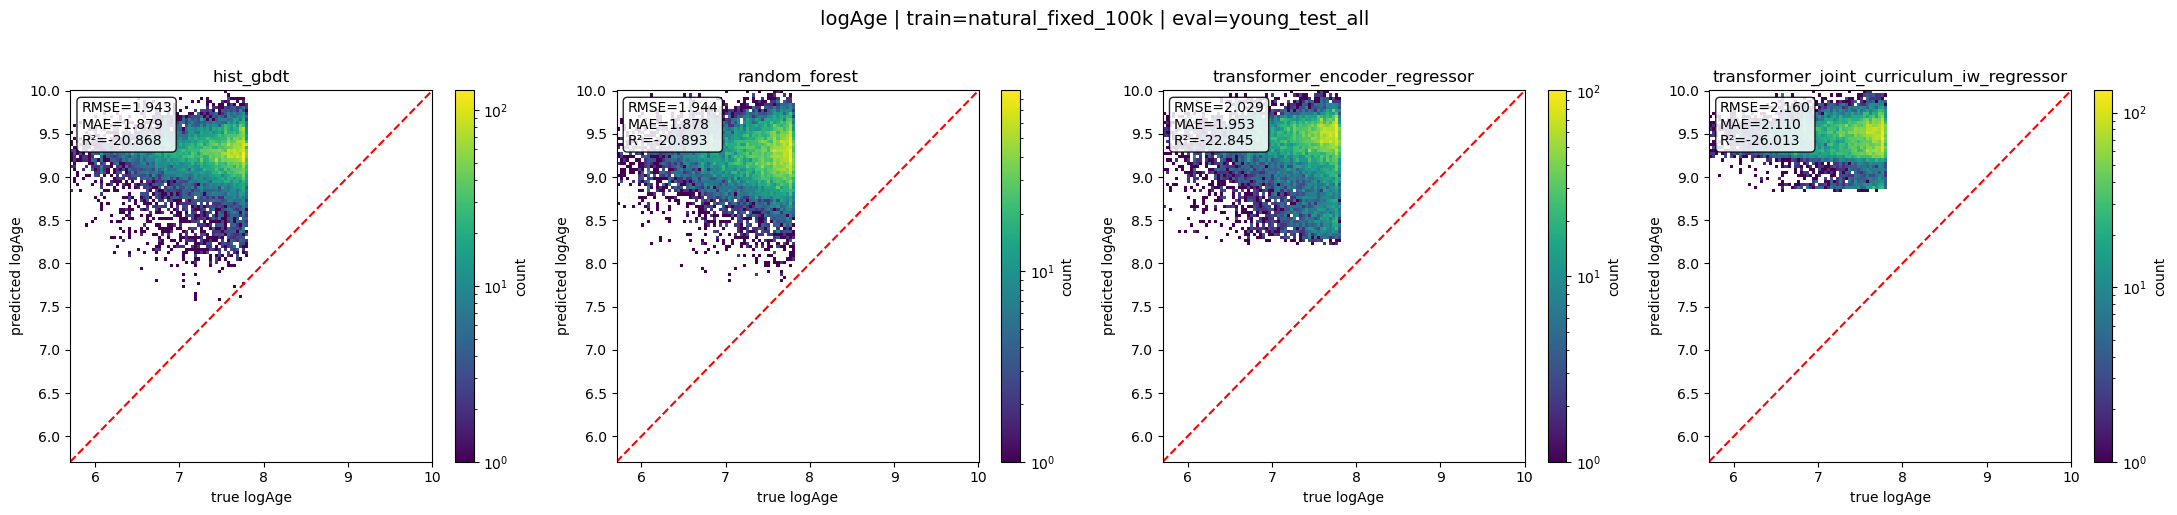

In [32]:
plot_cached_true_vs_pred_hist2d(
    target_col='logAge',
    train_subset_name='natural_fixed_100k',
    eval_subset_name='young_test_all',
)

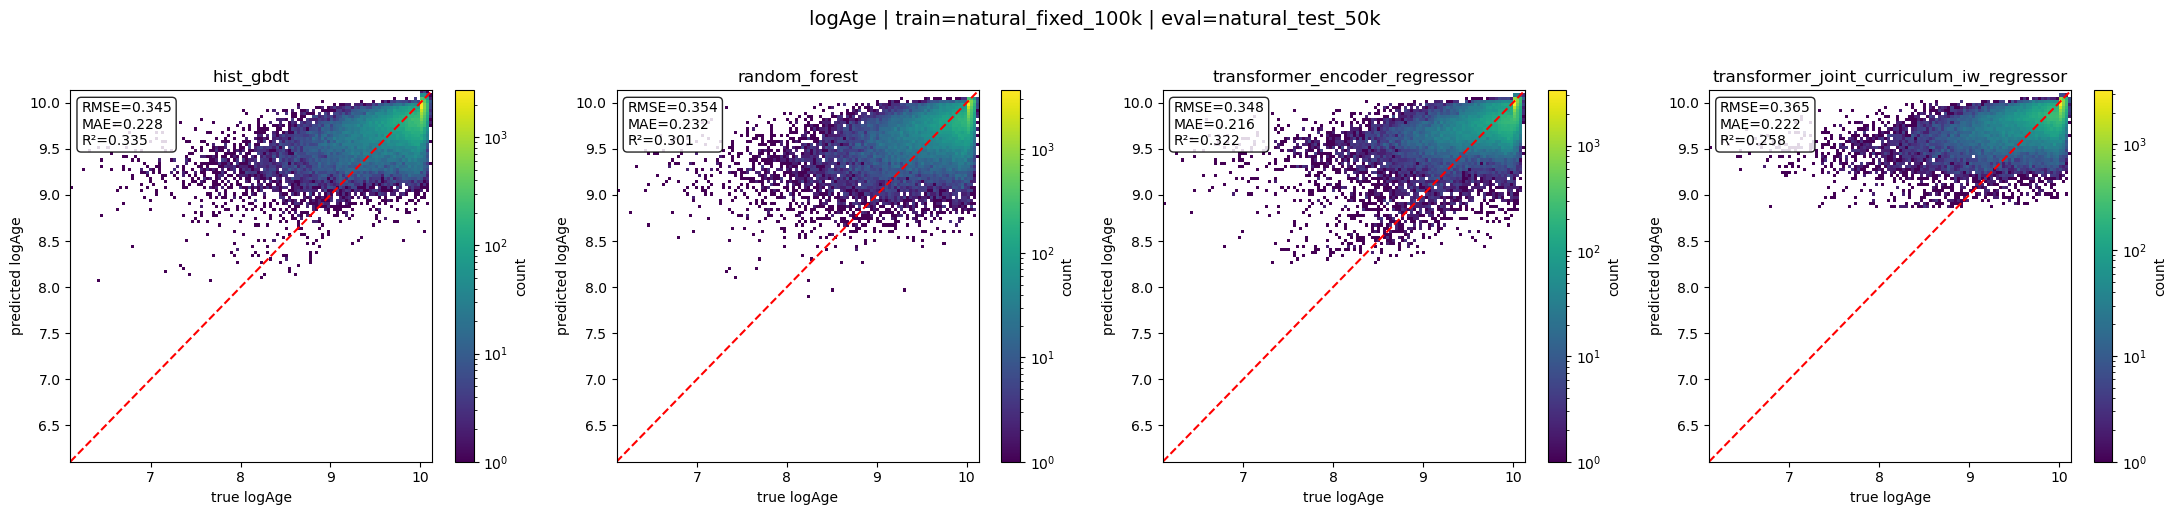

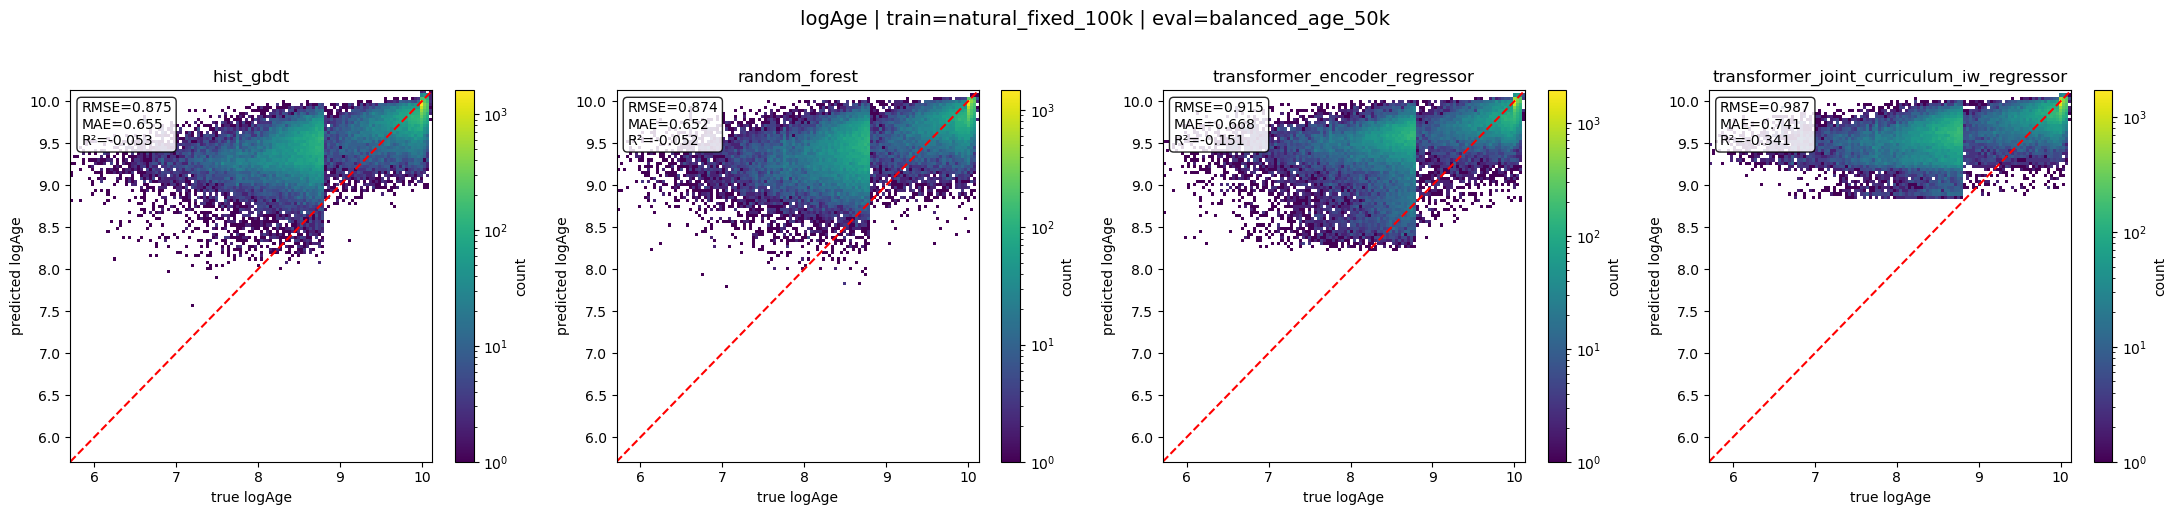

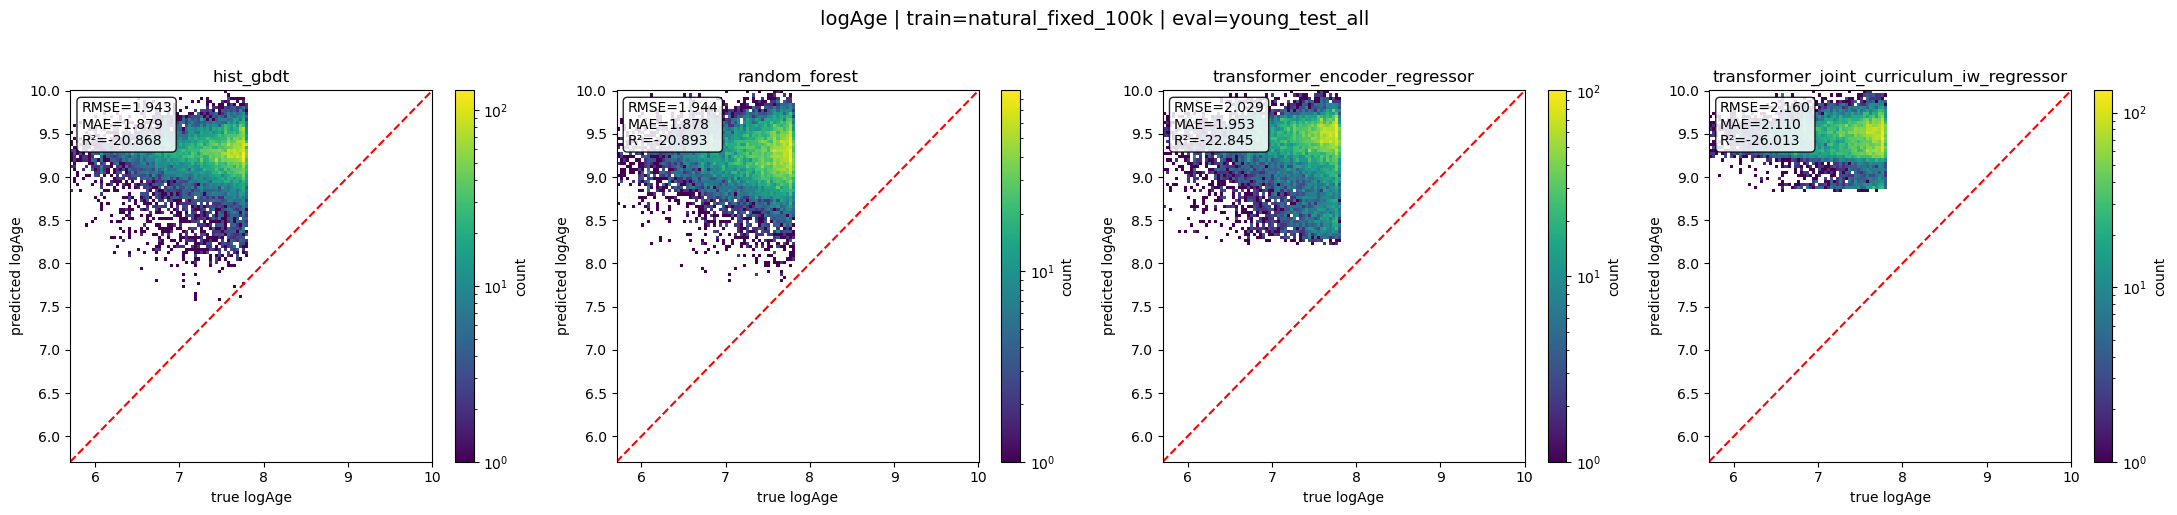

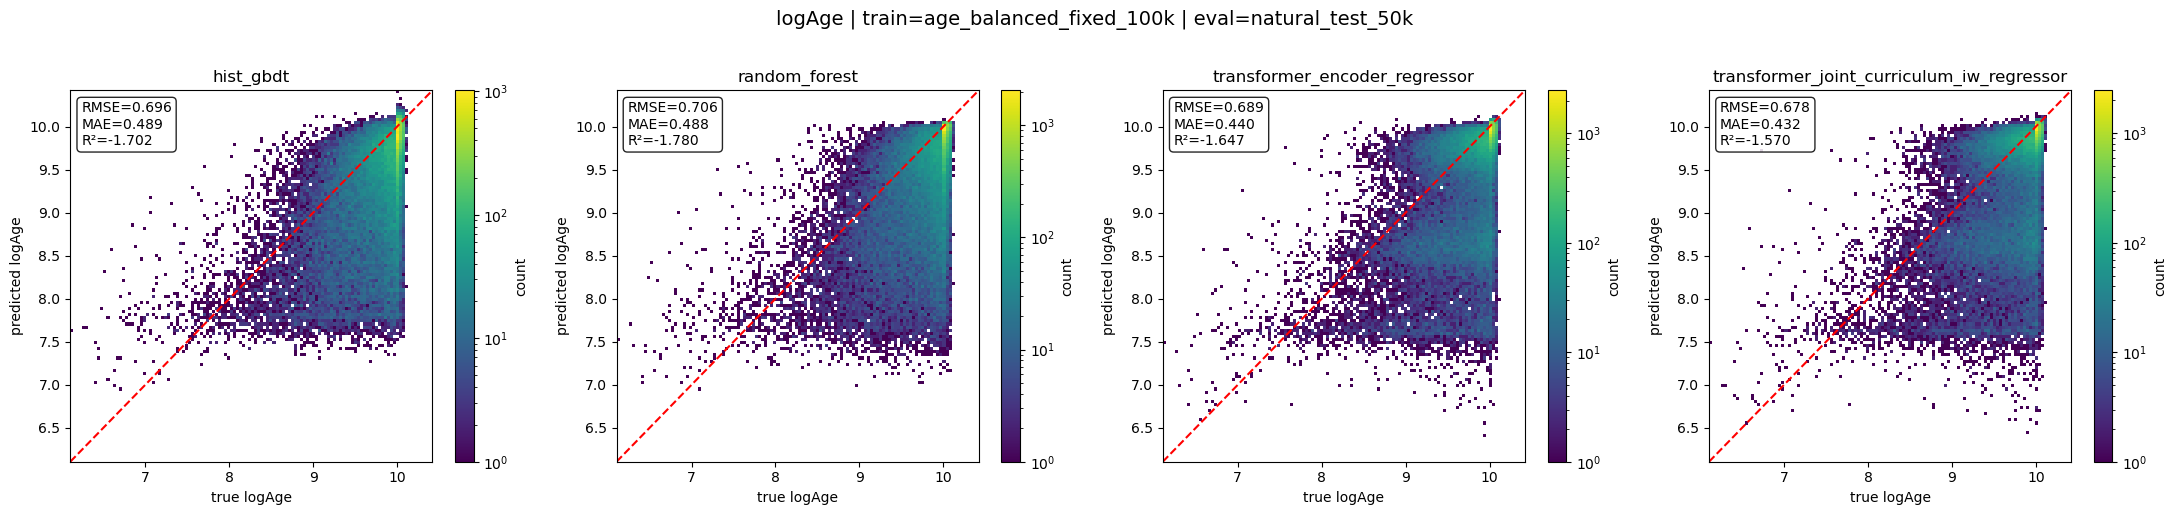

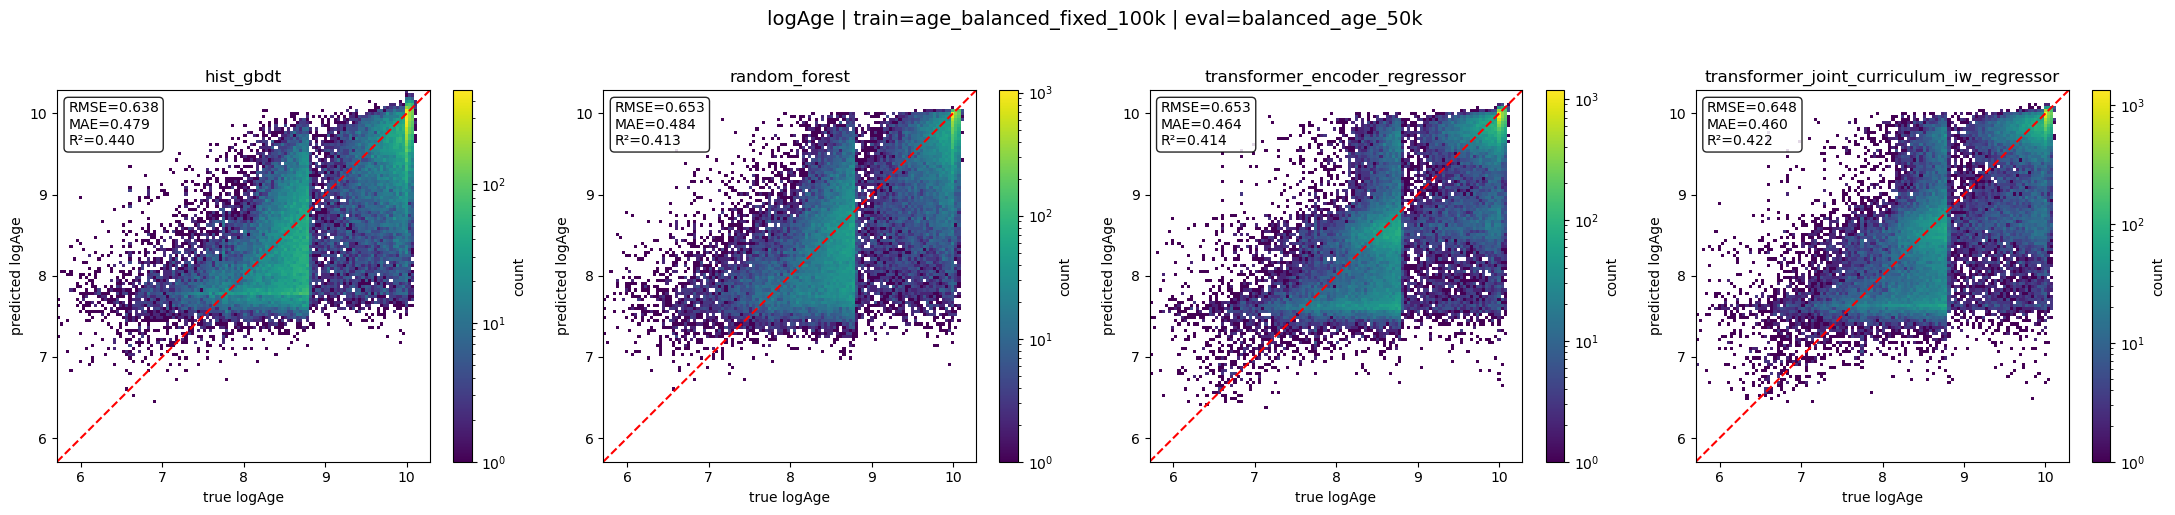

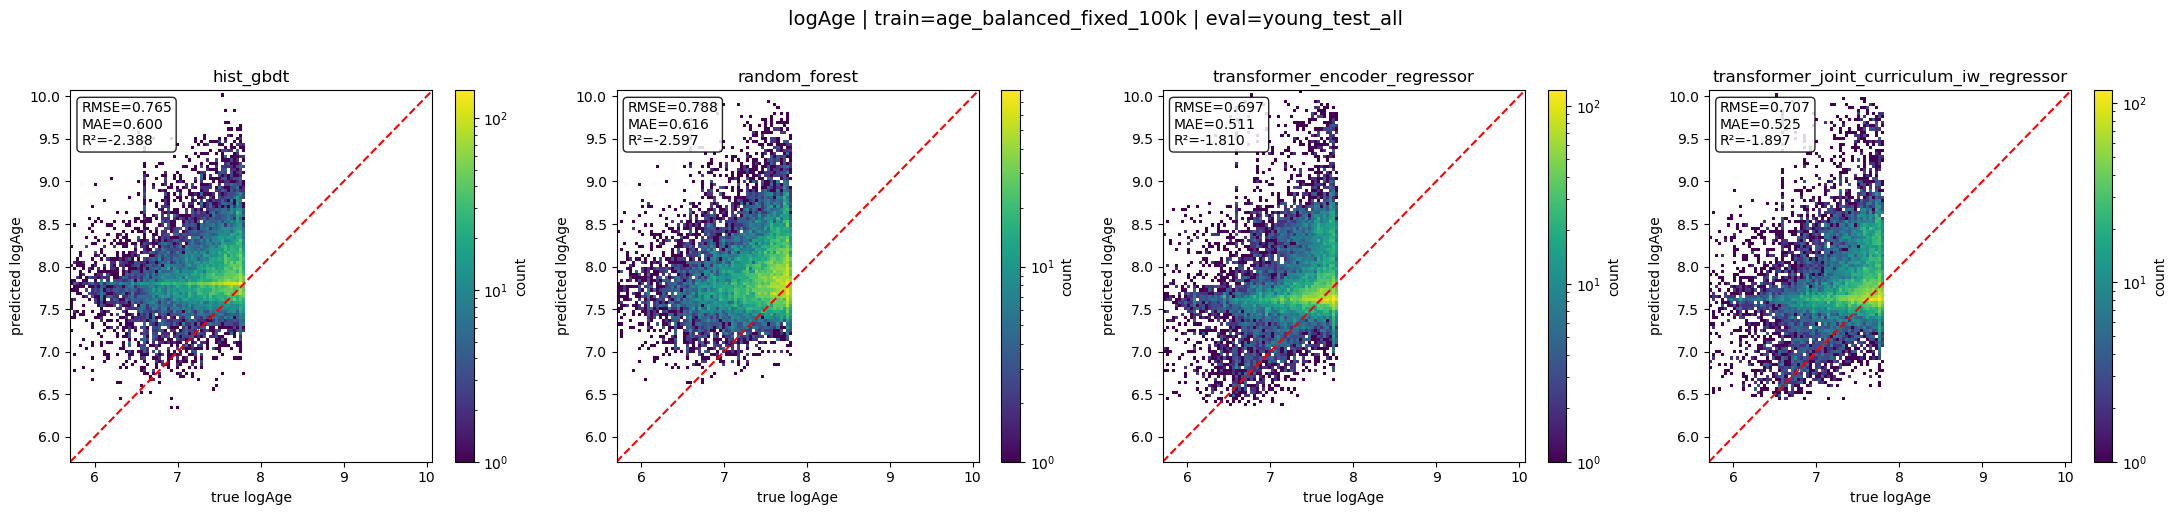

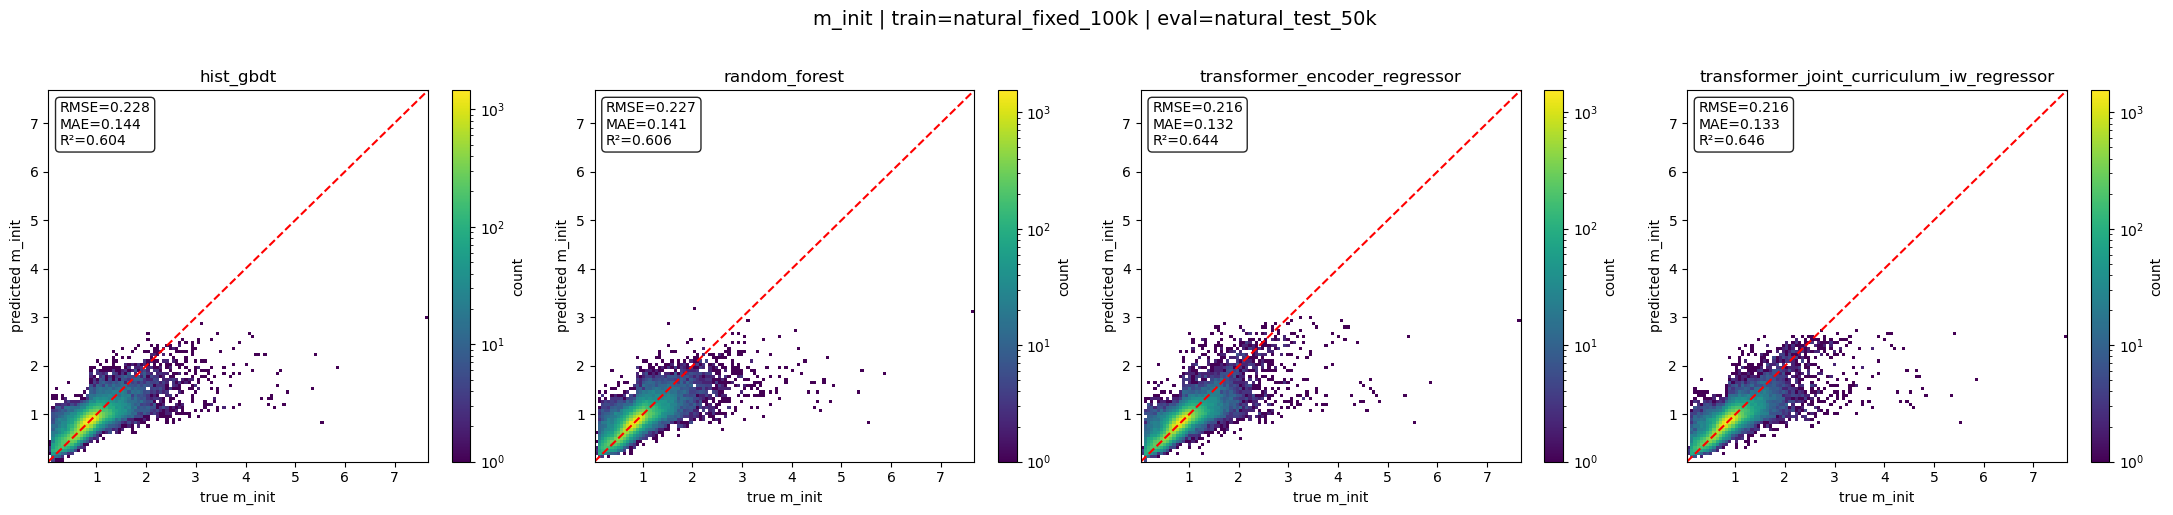

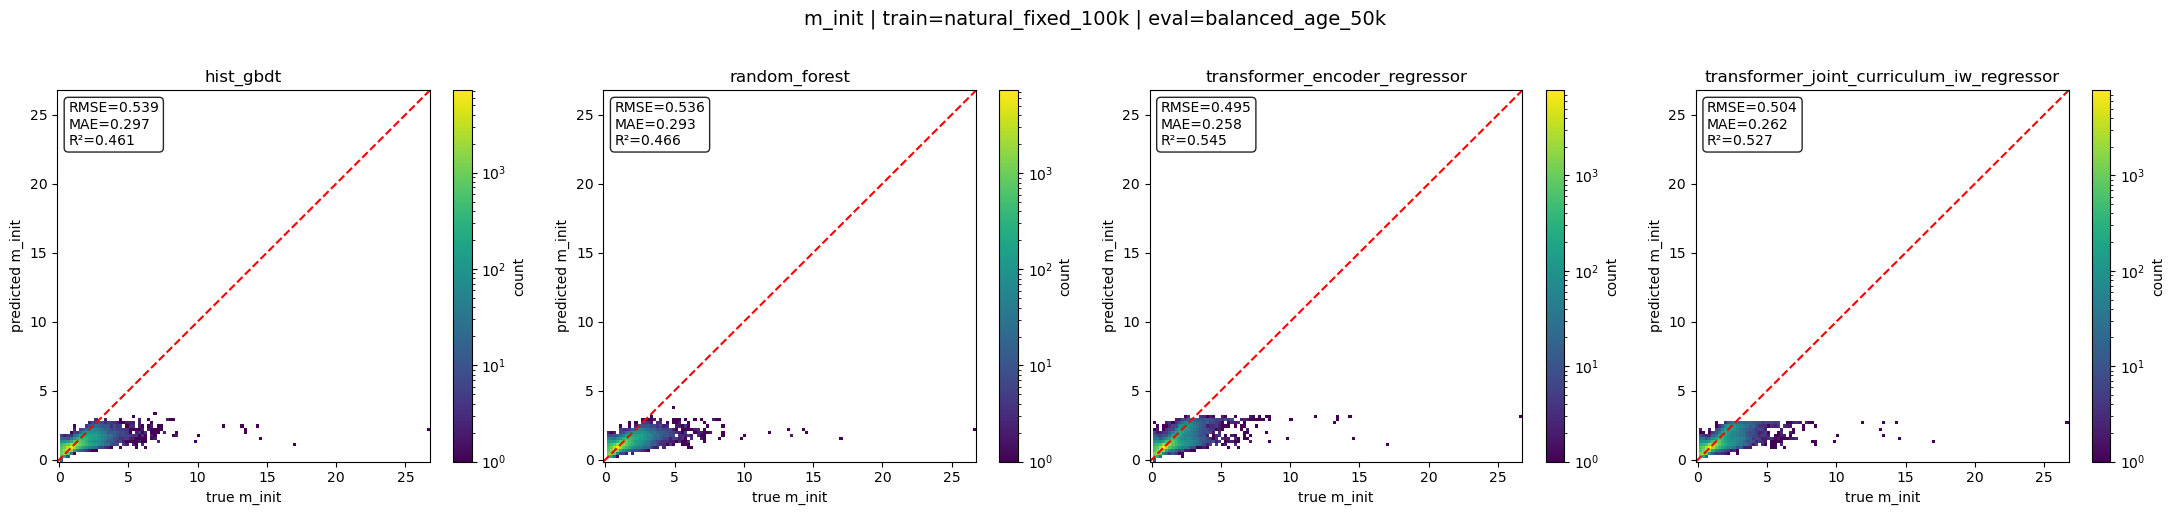

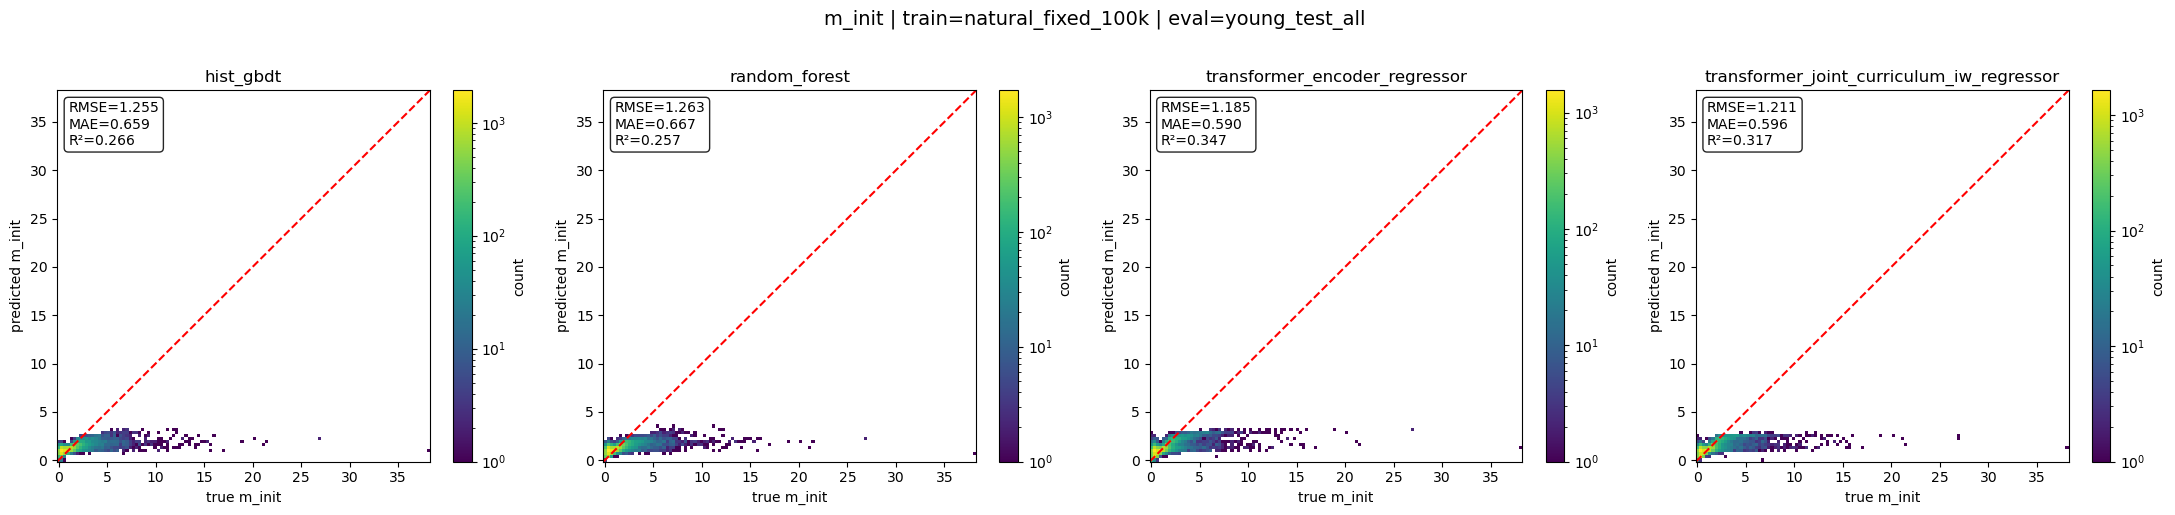

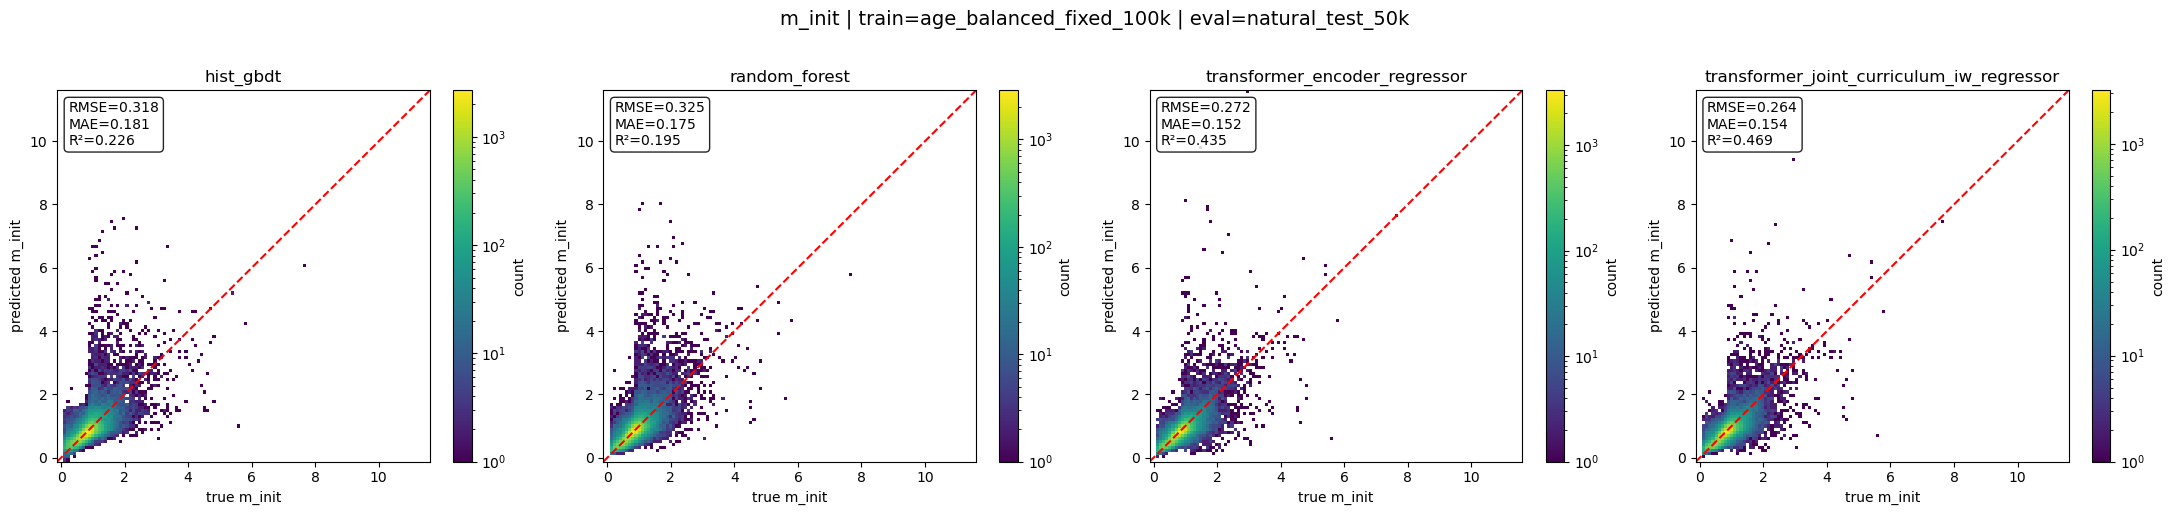

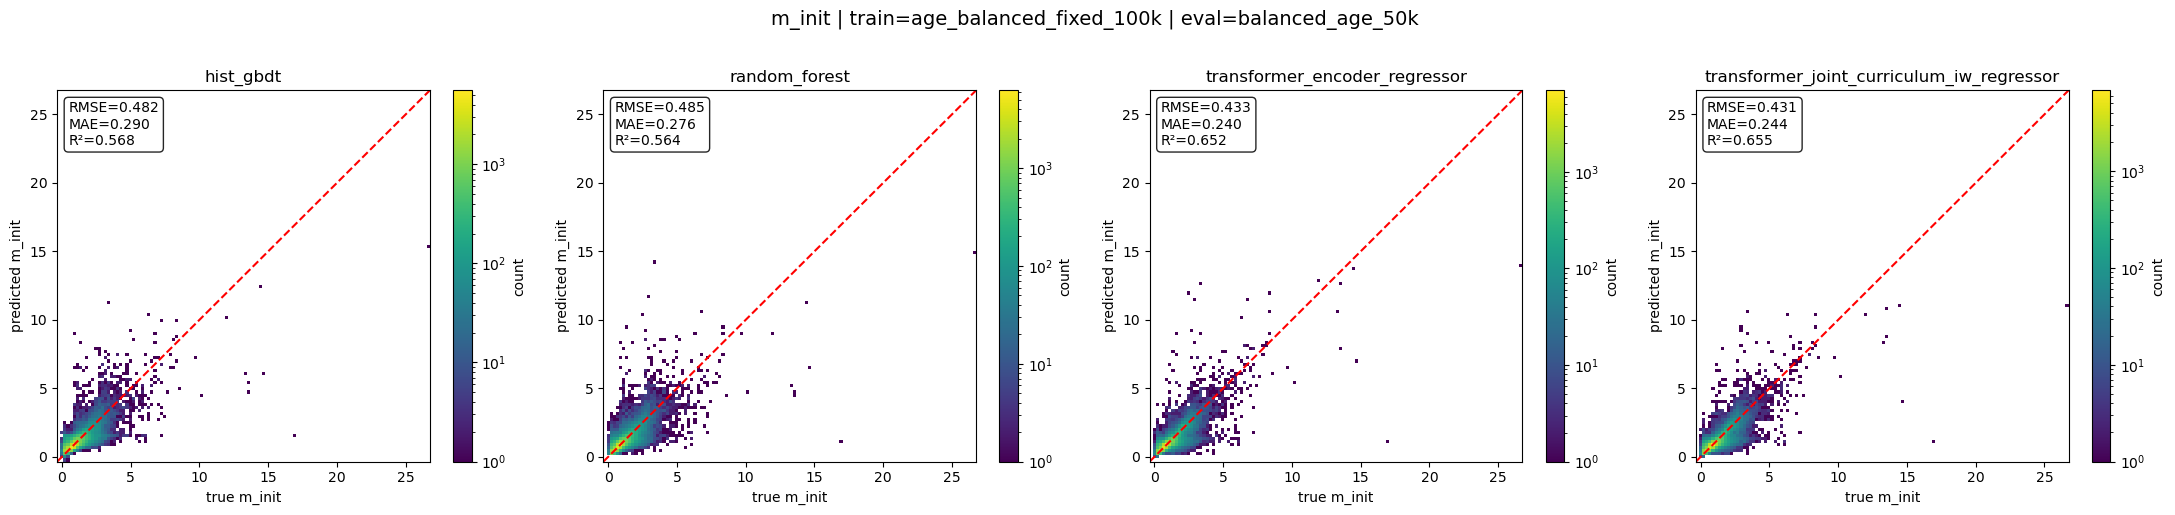

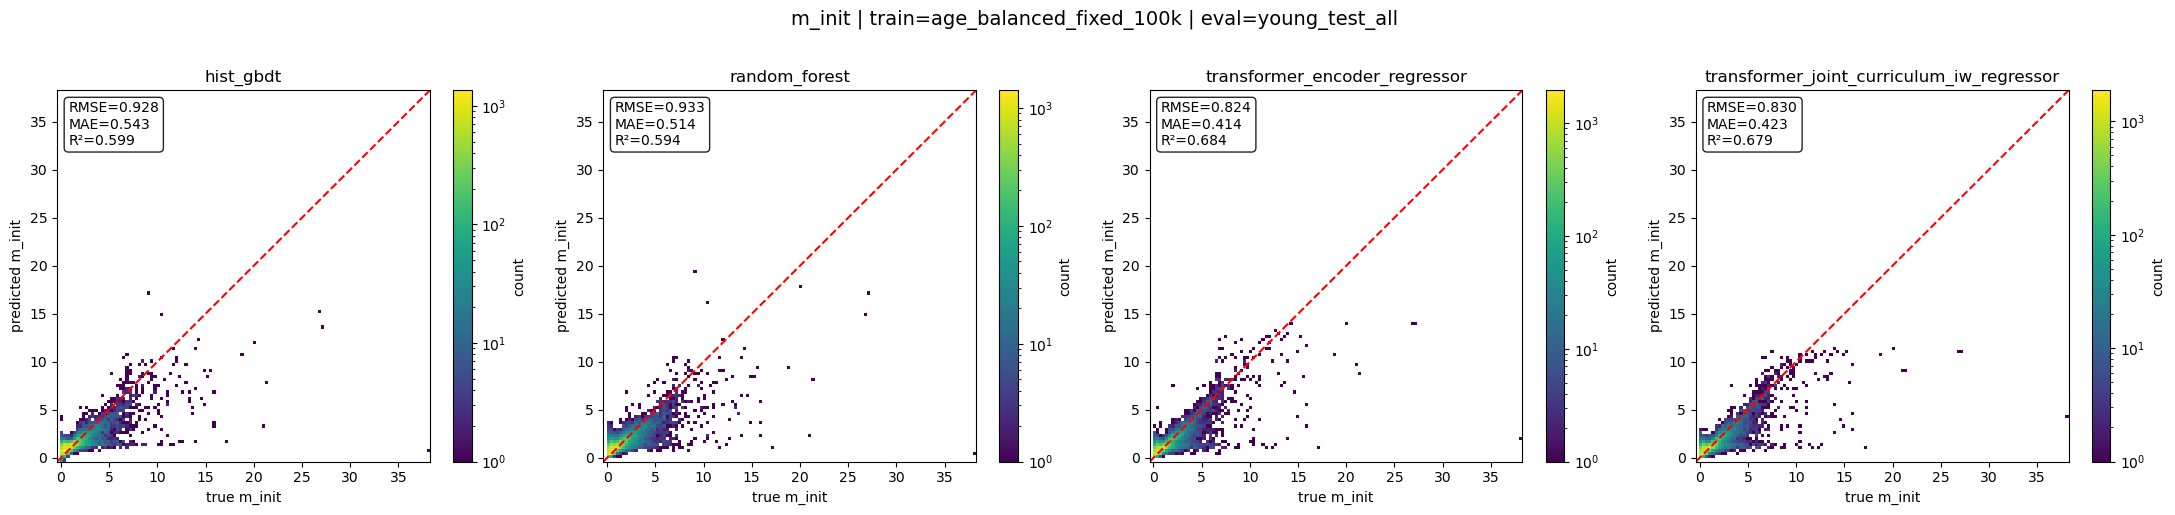

In [33]:
for target_col in TARGET_COLUMNS:
    for train_subset_name in train_subset_rows.keys():
        for eval_subset_name in eval_subset_rows.keys():
            plot_cached_true_vs_pred_hist2d(
                target_col=target_col,
                train_subset_name=train_subset_name,
                eval_subset_name=eval_subset_name,
            )


In [34]:
def summarize_logage_floor(train_subset_name, eval_subset_name):
    rows = []
    for model_name in MODEL_ORDER:
        key = ('logAge', train_subset_name, eval_subset_name, model_name)
        if key not in prediction_cache:
            continue
        y_true_norm, y_pred_norm = prediction_cache[key]
        y_true = denormalize_target(cache, y_true_norm, 'logAge')
        y_pred = denormalize_target(cache, y_pred_norm, 'logAge')
        train_true = denormalize_target(
            cache,
            build_sbi_arrays(
                cache,
                row_indices=train_subset_rows[train_subset_name],
                input_columns=INPUT_COLUMNS,
                theta_columns=['logAge'],
                use_colors=USE_COLORS,
            ).theta[:, 0],
            'logAge',
        )
        rows.append({
            'model': model_name,
            'train_min': float(np.min(train_true)),
            'true_min_eval': float(np.min(y_true)),
            'pred_min_eval': float(np.min(y_pred)),
            'pred_p01_eval': float(np.quantile(y_pred, 0.01)),
            'pred_p05_eval': float(np.quantile(y_pred, 0.05)),
            'true_p01_eval': float(np.quantile(y_true, 0.01)),
            'true_p05_eval': float(np.quantile(y_true, 0.05)),
            'frac_pred_below_7p8': float(np.mean(y_pred < 7.8)),
            'frac_true_below_7p8': float(np.mean(y_true < 7.8)),
        })
    return pd.DataFrame(rows).sort_values('pred_min_eval')


def plot_logage_floor_diagnostics(train_subset_name, eval_subset_name, *, n_bins=40):
    model_names = [m for m in MODEL_ORDER if ('logAge', train_subset_name, eval_subset_name, m) in prediction_cache]
    fig, axes = plt.subplots(len(model_names), 3, figsize=(16, 4 * len(model_names)), squeeze=False)

    for row_idx, model_name in enumerate(model_names):
        y_true_norm, y_pred_norm = prediction_cache[('logAge', train_subset_name, eval_subset_name, model_name)]
        y_true = denormalize_target(cache, y_true_norm, 'logAge')
        y_pred = denormalize_target(cache, y_pred_norm, 'logAge')
        residual = y_pred - y_true

        ax = axes[row_idx, 0]
        ax.hist(y_true, bins=60, alpha=0.5, label='true', density=True)
        ax.hist(y_pred, bins=60, alpha=0.5, label='pred', density=True)
        ax.axvline(7.8, color='k', ls='--', lw=1)
        ax.set_title(f'{model_name}: distribution')
        ax.set_xlabel('logAge')
        ax.legend()

        ax = axes[row_idx, 1]
        hb = ax.hexbin(y_true, y_pred, gridsize=50, mincnt=1, cmap='viridis')
        lim_lo = min(np.min(y_true), np.min(y_pred))
        lim_hi = max(np.max(y_true), np.max(y_pred))
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', lw=1)
        ax.axhline(7.8, color='k', ls=':', lw=1)
        ax.axvline(7.8, color='k', ls=':', lw=1)
        ax.set_title(f'{model_name}: true vs pred')
        ax.set_xlabel('true logAge')
        ax.set_ylabel('pred logAge')
        plt.colorbar(hb, ax=ax, label='count')

        ax = axes[row_idx, 2]
        bins = np.linspace(float(np.min(y_true)), float(np.max(y_true)), n_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])
        med = np.full(n_bins, np.nan)
        q10 = np.full(n_bins, np.nan)
        q90 = np.full(n_bins, np.nan)
        for i in range(n_bins):
            mask = (y_true >= bins[i]) & (y_true < bins[i + 1])
            if mask.sum() < 20:
                continue
            med[i] = np.median(y_pred[mask])
            q10[i] = np.quantile(y_pred[mask], 0.10)
            q90[i] = np.quantile(y_pred[mask], 0.90)
        ax.plot(centers, centers, 'k--', lw=1, label='ideal')
        ax.plot(centers, med, lw=2, label='pred median')
        ax.fill_between(centers, q10, q90, alpha=0.2, label='pred 10-90%')
        ax.axhline(7.8, color='k', ls=':', lw=1)
        ax.axvline(7.8, color='k', ls=':', lw=1)
        ax.set_title(f'{model_name}: binned response')
        ax.set_xlabel('true logAge')
        ax.set_ylabel('pred logAge')
        ax.legend()

    fig.suptitle(f'logAge floor diagnostics | train={train_subset_name} | eval={eval_subset_name}', y=1.01)
    plt.tight_layout()
    plt.show()


,model,train_min,true_min_eval,pred_min_eval,pred_p01_eval,pred_p05_eval,true_p01_eval,true_p05_eval,frac_pred_below_7p8,frac_true_below_7p8
0,hist_gbdt,5.850437,5.705208,7.570366,8.229347,8.669870,6.05679,6.501207,0.000498,1.0
1,random_forest,5.850437,5.705208,7.789511,8.363547,8.703078,6.05679,6.501207,0.000055,1.0
2,transformer_encoder_regressor,5.850437,5.705208,8.213883,8.349669,8.518823,6.05679,6.501207,0.000000,1.0
3,transformer_joint_curriculum_iw_regressor,5.850437,5.705208,8.849107,8.881698,9.097520,6.05679,6.501207,0.000000,1.0


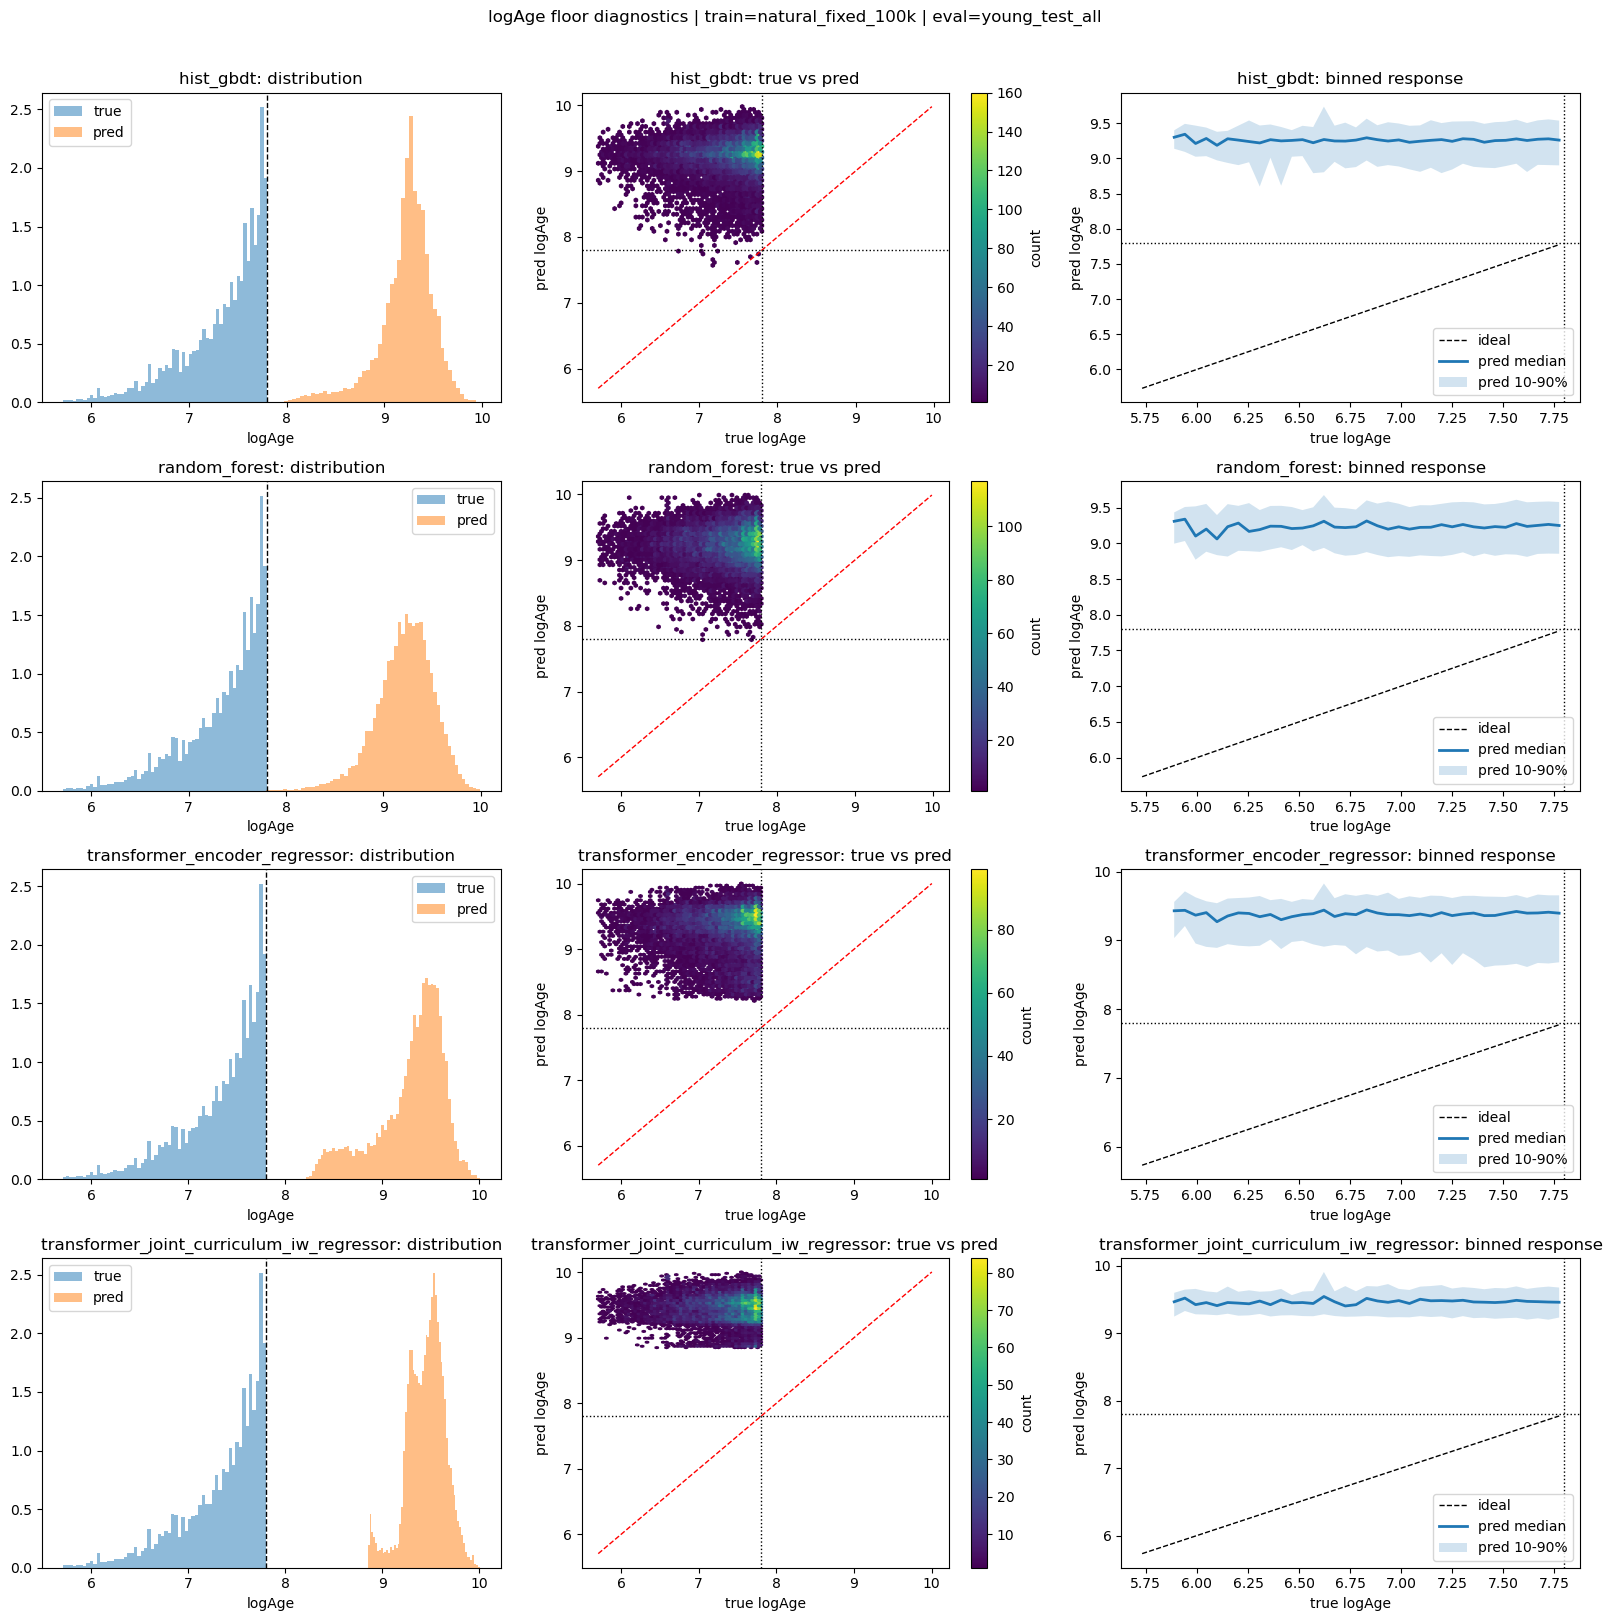

In [35]:
display(summarize_logage_floor('natural_fixed_100k', 'young_test_all'))
plot_logage_floor_diagnostics('natural_fixed_100k', 'young_test_all')

In [36]:
# Main summary table
results_df = cached_eval_results.sort_values(['target', 'eval_subset', 'rmse_phys', 'mae_phys']).copy()
display(results_df)

summary = (
    results_df
    .pivot_table(
        index=['target', 'train_subset', 'eval_subset'],
        columns='model',
        values=['rmse_phys', 'mae_phys', 'r2_phys', 'pred_min_phys', 'pred_p05_phys'],
    )
    .sort_index()
)
display(summary)


,target,train_subset,eval_subset,model,n_eval,rmse_norm,mae_norm,r2_norm,rmse_phys,mae_phys,r2_phys,pred_min_phys,pred_p01_phys,pred_p05_phys
19,logAge,age_balanced_fixed_100k,balanced_age_50k,hist_gbdt,50000,1.559311,1.170980,0.439564,0.638209,0.479270,0.439564,6.455687,7.484079,7.678966
17,logAge,age_balanced_fixed_100k,balanced_age_50k,transformer_joint_curriculum_iw_regressor,50000,1.584134,1.124377,0.421578,0.648369,0.460196,0.421578,6.462118,7.254780,7.559023
16,logAge,age_balanced_fixed_100k,balanced_age_50k,transformer_encoder_regressor,50000,1.594767,1.134474,0.413787,0.652721,0.464328,0.413787,6.381327,7.267284,7.555424
18,logAge,age_balanced_fixed_100k,balanced_age_50k,random_forest,50000,1.595392,1.183558,0.413328,0.652977,0.484417,0.413328,6.618418,7.390987,7.616159
6,logAge,natural_fixed_100k,balanced_age_50k,random_forest,50000,2.136600,1.593906,-0.052222,0.874488,0.652368,-0.052222,7.789511,8.628228,8.925751
7,logAge,natural_fixed_100k,balanced_age_50k,hist_gbdt,50000,2.137114,1.600565,-0.052728,0.874698,0.655094,-0.052728,7.570366,8.563739,8.979835
4,logAge,natural_fixed_100k,balanced_age_50k,transformer_encoder_regressor,50000,2.234708,1.631748,-0.151072,0.914642,0.667857,-0.151072,8.213883,8.442613,8.751672
5,logAge,natural_fixed_100k,balanced_age_50k,transformer_joint_curriculum_iw_regressor,50000,2.412234,1.811428,-0.341219,0.987302,0.741398,-0.341219,8.851962,8.941290,9.239945
3,logAge,natural_fixed_100k,natural_test_50k,hist_gbdt,50000,0.843140,0.557935,0.335103,0.345088,0.228357,0.335103,8.056438,9.041383,9.274131
0,logAge,natural_fixed_100k,natural_test_50k,transformer_encoder_regressor,50000,0.851188,0.528325,0.322349,0.348382,0.216238,0.322349,8.267807,8.918993,9.348483


mae_phys                \
model                                           hist_gbdt random_forest   
target train_subset            eval_subset                                
logAge age_balanced_fixed_100k balanced_age_50k  0.479270      0.484417   
                               natural_test_50k  0.489407      0.488007   
                               young_test_all    0.599940      0.615867   
       natural_fixed_100k      balanced_age_50k  0.655094      0.652368   
                               natural_test_50k  0.228357      0.232483   
                               young_test_all    1.878586      1.878474   
m_init age_balanced_fixed_100k balanced_age_50k  0.290412      0.276254   
                               natural_test_50k  0.180569      0.175399   
                               young_test_all    0.543225      0.513612   
       natural_fixed_100k      balanced_age_50k  0.296681      0.292794   
                               natural_test_50k  0.144127      0.141245   
                               young_test_all    0.659378      0.667239   

                                                                               \
model                                           transformer_encoder_regressor   
target train_subset            eval_subset                                      
logAge age_balanced_fixed_100k balanced_age_50k                      0.464328   
                               natural_test_50k                      0.440448   
                               young_test_all                        0.511201   
       natural_fixed_100k      balanced_age_50k                      0.667857   
                               natural_test_50k                      0.216238   
                               young_test_all                        1.953155   
m_init age_balanced_fixed_100k balanced_age_50k                      0.239868   
                               natural_test_50k                      0.152117   
                               young_test_all                        0.414403   
       natural_fixed_100k      balanced_age_50k                      0.257946   
                               natural_test_50k                      0.131576   
                               young_test_all                        0.589847   

                                                                                           \
model                                           transformer_joint_curriculum_iw_regressor   
target train_subset            eval_subset                                                  
logAge age_balanced_fixed_100k balanced_age_50k                                  0.460196   
                               natural_test_50k                                  0.431753   
                               young_test_all                                    0.524820   
       natural_fixed_100k      balanced_age_50k                                  0.741398   
                               natural_test_50k                                  0.222380   
                               young_test_all                                    2.109870   
m_init age_balanced_fixed_100k balanced_age_50k                                  0.243593   
                               natural_test_50k                                  0.153564   
                               young_test_all                                    0.422526   
       natural_fixed_100k      balanced_age_50k                                  0.262381   
                               natural_test_50k                                  0.132693   
                               young_test_all                                    0.595782   

                                                pred_min_phys                \
model                                               hist_gbdt random_forest   
target train_subset            eval_subset                                    
logAge age_balanced_fixed_100k balanced_age_50k      6.455687      6.61841

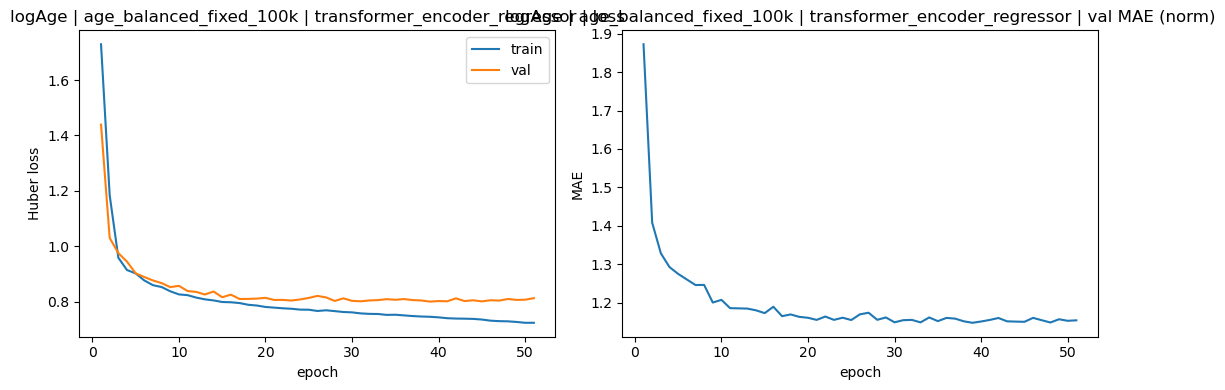

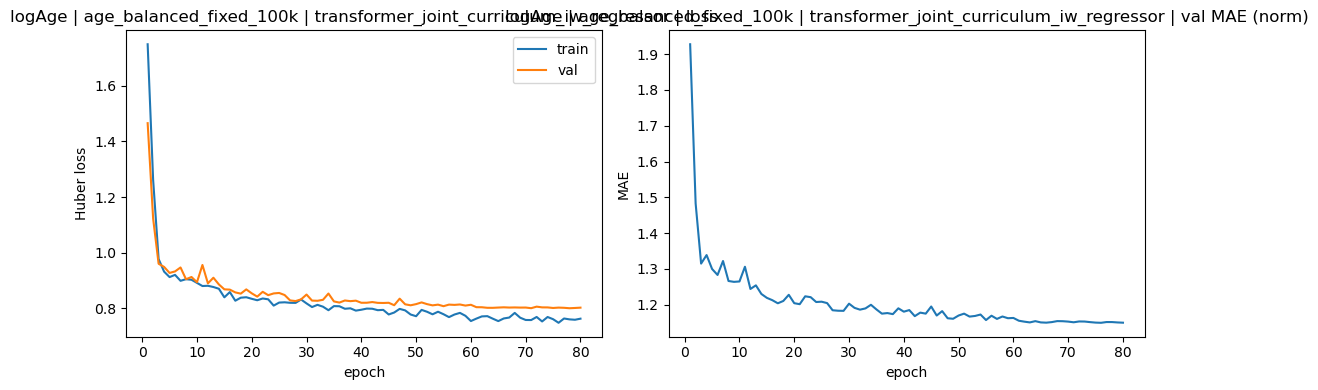

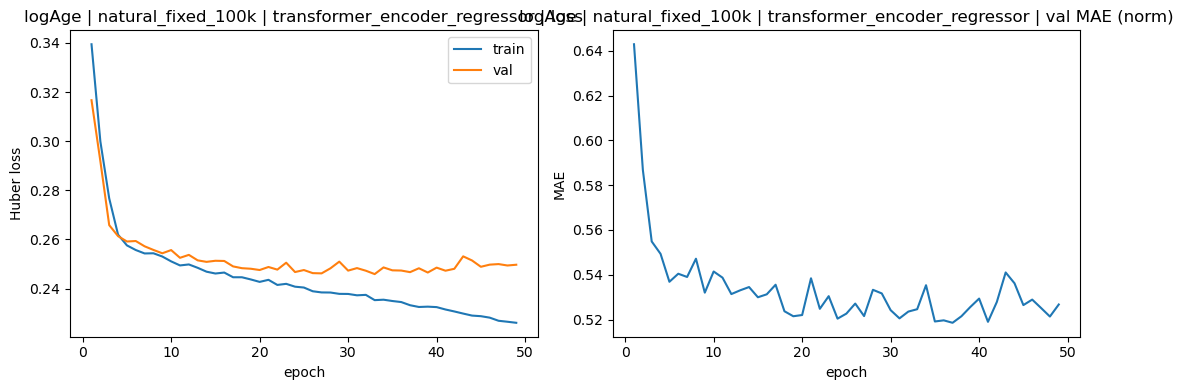

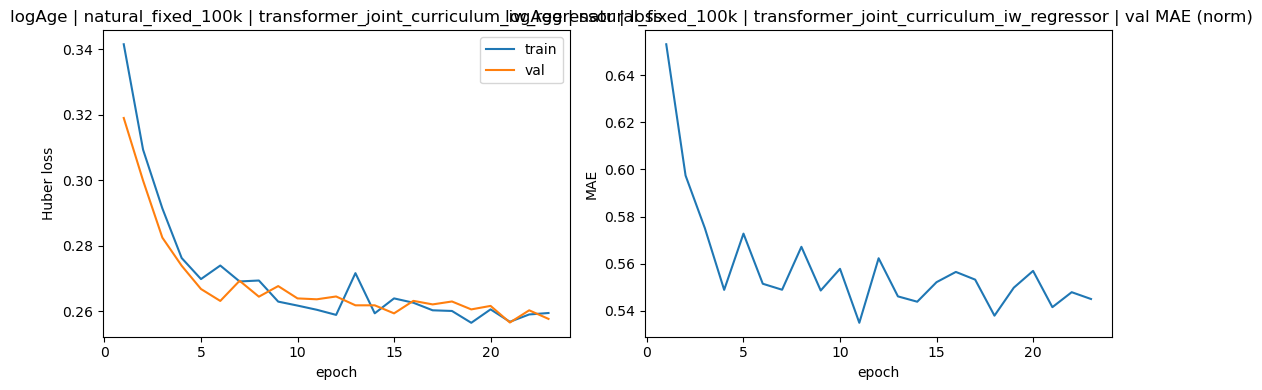

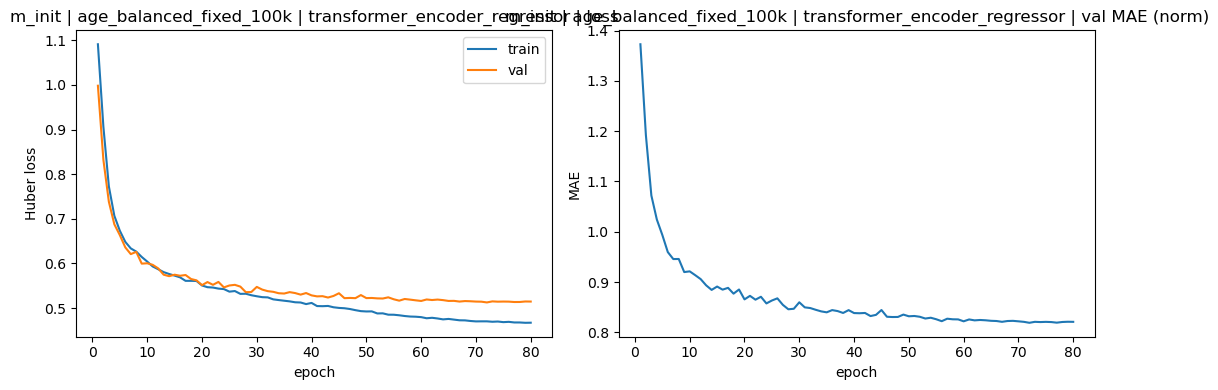

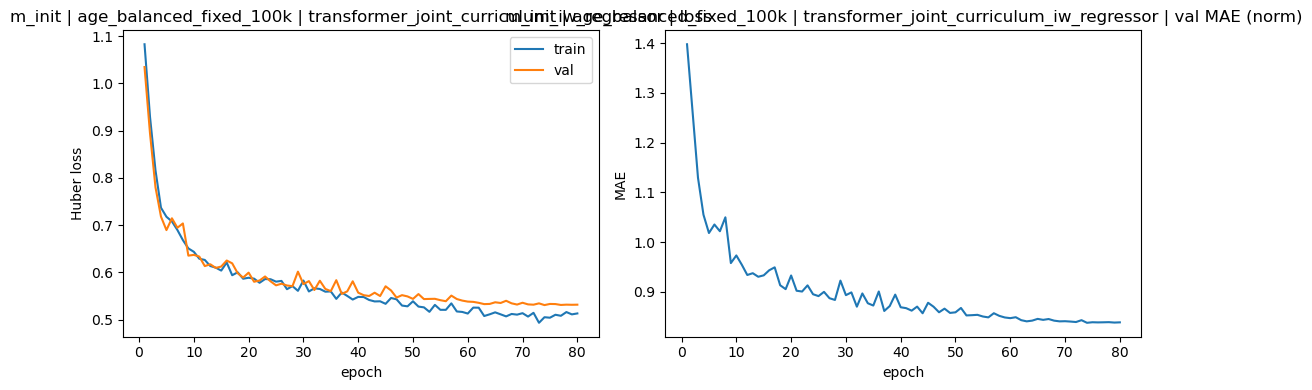

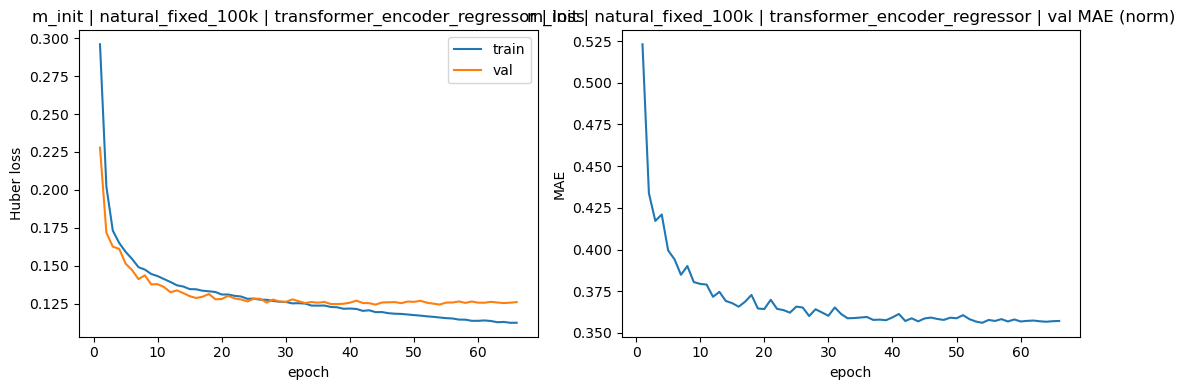

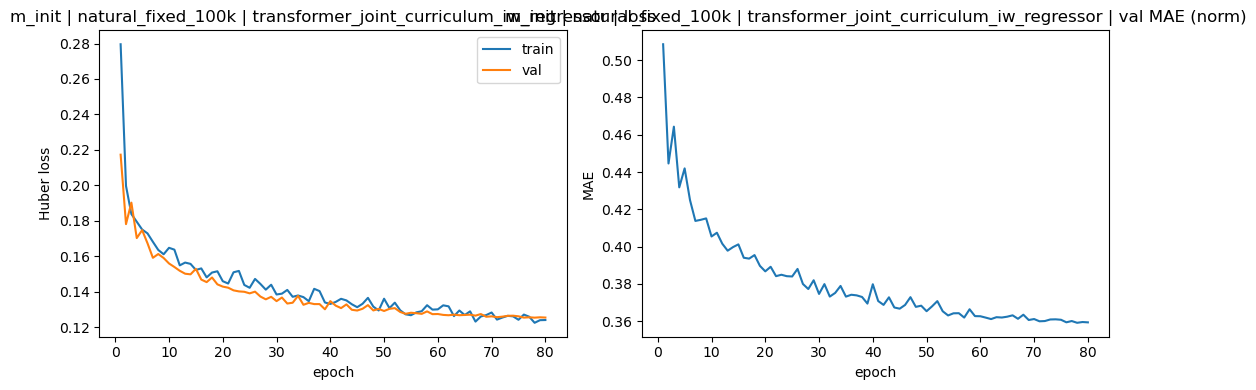

In [38]:
# Plot transformer training curves
for (target_col, subset_name, model_name), group in history_df.groupby(['target', 'train_subset', 'model']):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(group['epoch'], group['train_loss'], label='train')
    axes[0].plot(group['epoch'], group['val_loss'], label='val')
    axes[0].set_title(f'{target_col} | {subset_name} | {model_name} | loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('Huber loss')
    axes[0].legend()

    axes[1].plot(group['epoch'], group['val_mae_norm'])
    axes[1].set_title(f'{target_col} | {subset_name} | {model_name} | val MAE (norm)')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('MAE')
    plt.tight_layout()
    plt.show()



## Notes

A few interpretation points:

- This notebook now uses the fixed split assets from `age_regime_splits` plus the dedicated `young_test_indices_logAge_lt_7p8.npy` set.
  That makes the transformer and tabular baselines directly comparable to the newer SBI evaluations.
- The transformer comparison now includes two variants:
  - `transformer_encoder_regressor`: plain shuffled minibatches
  - `transformer_joint_curriculum_iw_regressor`: joint `(logAge, m_init)` curriculum sampling with importance weights
- The random-forest and histogram-GBDT baselines are intentionally kept in place.
  They remain the main tabular references for whether the transformer is actually adding value.
- The `logAge` floor diagnostics are meant to answer whether an apparent lower cutoff is a bug or a modeling effect.
  Check these first:
  - prediction distribution vs truth distribution
  - true-vs-pred hexbin on `young_test_all`
  - binned median predicted `logAge` as a function of true `logAge`
  - minimum / low-quantile predicted `logAge` relative to the train-set minimum
- If the floor appears on train, val, and test, and there is no clipping in normalized space, it is probably a learned collapse rather than an implementation bug.
- The transformer now trains longer (`80` epochs, patience `12`) because the earlier `40` epoch setup was too weak to treat as a stable conclusion.
- If you want an even heavier benchmark later, the clean extensions are:
  - larger fixed train subsets
  - more targets
  - a third transformer variant without importance weights but with curriculum sampling


In [39]:
print('asdf')

asdf
